### Documentación de las KAN

https://kindxiaoming.github.io/pykan/

Artículo de las KAN 

https://arxiv.org/abs/2404.19756

Git

https://github.com/KindXiaoming/pykan

Otro git interesante
https://github.com/mintisan/awesome-kan

### Intalación del ambiente

Pre-requisitos:
* Python 3.9.7 a mayor

Requerimientos

* matplotlib==3.6.2
* numpy==1.24.4
* scikit_learn==1.1.3
* setuptools==65.5.0
* sympy==1.11.1
* torch==2.2.2
* tqdm==4.66.2
* pandas==2.0.1
* seaborn
* pyyaml

Crear el archivo de requerimientos

En colab

%pip install pykan==0.2.8

### Crear un ambiente virtual
#### Windows
PowerShell o Anaconda Prompt y ejecutar:

* python -m venv kan-env

En caso de tener diferentes versiones de python se puede indicar que version de python queremos en el ambiente, ademas si se tiene 3.10 se usar:
Para ver las versiones que detecta windows
* py -0p 
* py -3.9 -m venv kan-env

Para borar un ambiente se usa
* rm -r -fo .\kan-env

Activar el ambiente:

* kan-env\Scripts\activate

Actualizar pip:

* python -m pip install --upgrade pip

Instalar librerías:
requirements.txt tiene que estar en el folder al que apunta el powershell

* python -m pip install -r requirements.txt

Registrar el ambiente como kernel:

* python -m ipykernel install --user --name kan-env --display-name "Python (KAN)"


Después en VS Code:

Cierra y vuelve a abrir VS Code, o usa:

* Ctrl + Shift + P

Busca:

* Developer: Reload Window

Abre tu libreta .ipynb.

Arriba a la derecha selecciona el kernel:

* Python (KAN)


En caso de que falle el plot:
* python -m pip install "matplotlib-inline==0.1.6"

Si se quiere que detecte la tarjeta de video usar o instalar 

* pip uninstall torch torchvision torchaudio -y
* pip install torch==2.2.2+cu121 torchvision==0.17.2+cu121 torchaudio==2.2.2+cu121 --index-url https://download.pytorch.org/whl/cu121

#### MAC OS

Crear ambiente virtual
* python3 -m venv kan-env

Activar ambiente
* source kan-env/bin/activate

Actualizar pip
* python -m pip install --upgrade pip 

Instalar todo desde requirements.txt
* pip install -r requirements.txt

Registrar kernel en Jupyter
* python -m ipykernel install --user --name kan-env --display-name "Python (KAN)"

In [1]:
from kan import *

In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.2.2+cu121
True
12.1


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")   # Windows/Linux con NVIDIA
elif torch.backends.mps.is_available():
    #device = torch.device("mps")
    device = torch.device("cpu")     # macOS con Apple Silicon
else:
    device = torch.device("cpu")    # CPU

print("Usando dispositivo:", device)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version usada por PyTorch:", torch.version.cuda)

Usando dispositivo: cuda
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA version usada por PyTorch: 12.1


Ejemplo:

$$
f(x,y)=xy
$$

donde:

- $x$ es la primera variable de entrada,
- $y$ es la segunda variable de entrada,
- $f(x,y)$ es la salida que queremos que la KAN aprenda.

In [4]:
# =====================================================
# 2. Definir la función objetivo
# =====================================================
f = lambda x: x[:, [0]] * x[:, [1]]

In [5]:
# =====================================================
# 3. Crear dataset sintético
# =====================================================
dataset = create_dataset(
    f,
    n_var=2,
    train_num=1000,
    test_num=1000,
    device=device
)

print("Dataset creado:")
print(dataset.keys())

Dataset creado:
dict_keys(['train_input', 'test_input', 'train_label', 'test_label'])


| Parámetro        | Significado                             |
| ---------------- | --------------------------------------- |
| `f`              | función que queremos aprender           |
| `n_var=2`        | la función tiene 2 variables de entrada |
| `train_num=1000` | genera 1000 datos de entrenamiento      |
| `test_num=1000`  | genera 1000 datos de prueba             |
| `device=device`  | guarda los tensores en CPU o GPU        |


In [6]:
print("Primeras 5 muestras de entrenamiento:")
print("Entradas (train_input):")
print(dataset['train_input'][:5])
print("-" * 90)
print("Etiquetas (train_label):")
print(dataset['train_label'][:5])

Primeras 5 muestras de entrenamiento:
Entradas (train_input):
tensor([[-0.0075,  0.5547],
        [ 0.5364,  0.1791],
        [-0.8230,  0.1526],
        [-0.7359,  0.5171],
        [-0.3852,  0.6230]], device='cuda:0')
------------------------------------------------------------------------------------------
Etiquetas (train_label):
tensor([[-0.0042],
        [ 0.0961],
        [-0.1256],
        [-0.3805],
        [-0.2400]], device='cuda:0')


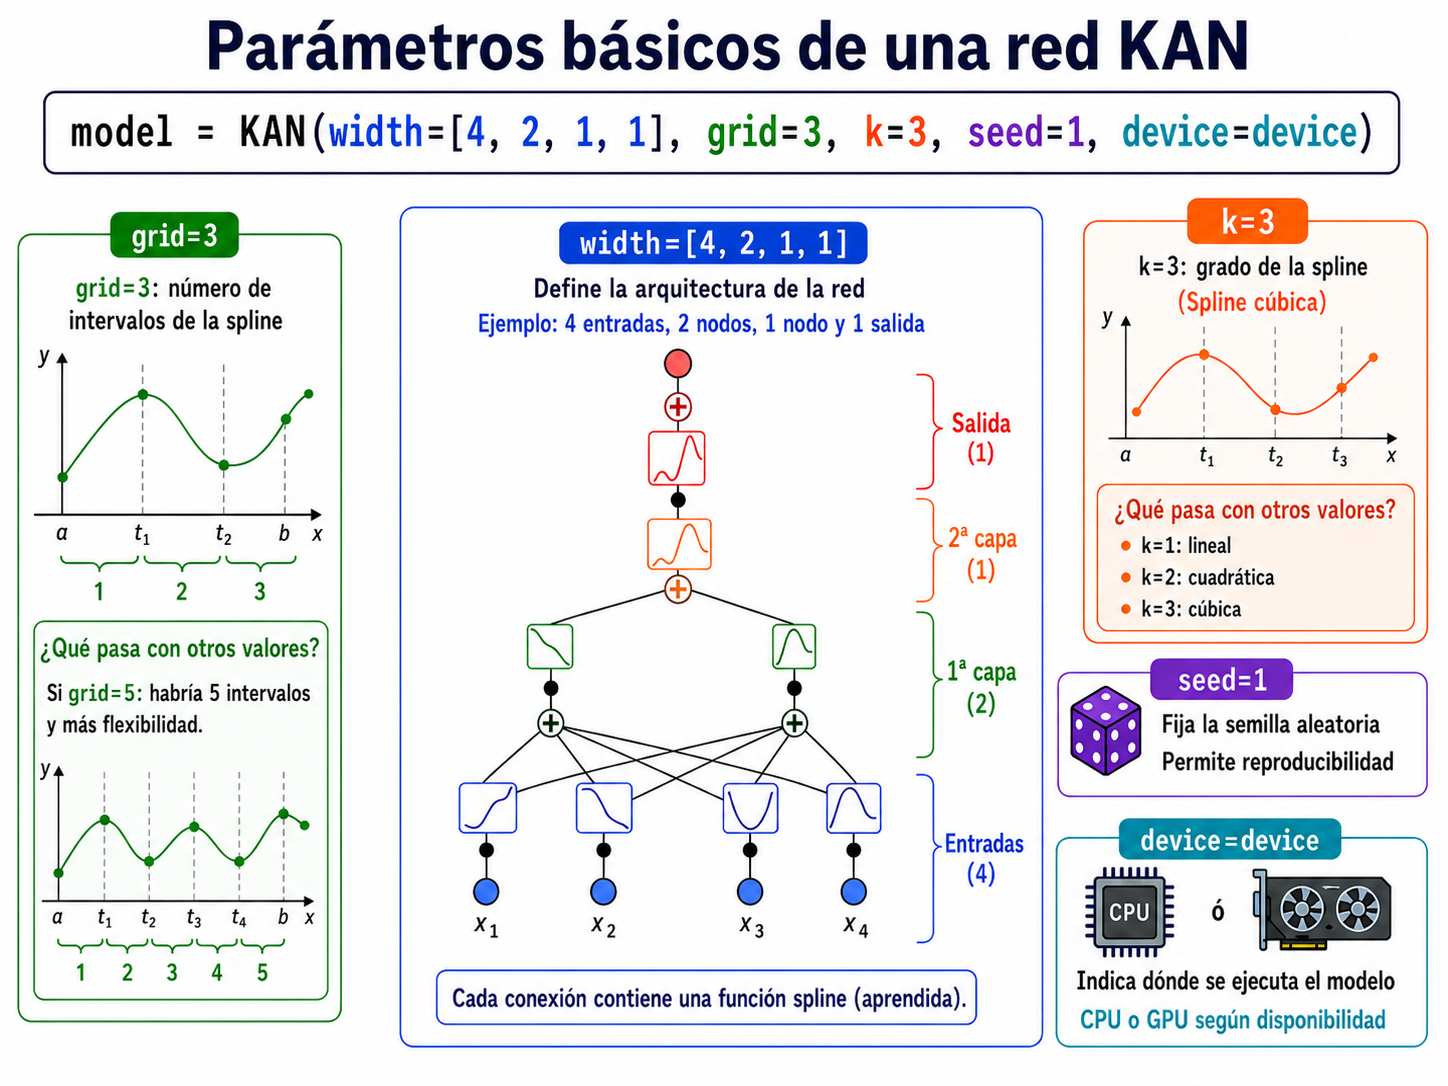

In [7]:
# =====================================================
# 4. Crear modelo KAN
# =====================================================
import os
os.makedirs("./checkpoints_xy", exist_ok=True)

model = KAN(
    width=[2, 2, 1],
    grid=3,
    k=3,
    seed=1,
    device=device,
    ckpt_path="./checkpoints_xy"
    #auto_save=True
    #auto_save=False si no se quieren guardar los checkpoints durante el entrenamiento
)

checkpoint directory created: ./checkpoints_xy
saving model version 0.0


In [8]:
# =====================================================
# 5. Entrenar modelo
# =====================================================
results = model.fit(
    dataset,
    opt="LBFGS",
    steps=20
)

description:   0%|                                                           | 0/20 [00:00<?, ?it/s]

| train_loss: 1.23e-03 | test_loss: 1.15e-03 | reg: 7.71e+00 | : 100%|█| 20/20 [00:17<00:00,  1.16it

saving model version 0.1


| Opción    | Valor que pusiste | ¿Qué significa?                                            | Otros valores que podrías usar                                                                                                           |
| --------- | ----------------: | ---------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| `dataset` |         `dataset` | Es el diccionario con los datos de entrenamiento y prueba. | Otro diccionario creado con `create_dataset(...)` o uno armado manualmente con `train_input`, `train_label`, `test_input`, `test_label`. |
| `opt`     |         `"LBFGS"` | Es el optimizador usado para ajustar la KAN.               | `"LBFGS"` o `"Adam"`. Para ejemplos pequeños, `LBFGS` suele funcionar muy bien. L-BFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a popular quasi-Newton optimization algorithm used to find the local minimum of unconstrained, large-scale nonlinear problems                                                          |
| `steps`   |              `20` | Número de pasos de entrenamiento.                          | `5`, `10`, `20`, `50`, `100`, `200`. Para taller, usaría `20` o `50`.                                                                    |


In [9]:
print("Resultados del entrenamiento:")
print(results.keys())

Resultados del entrenamiento:
dict_keys(['train_loss', 'test_loss', 'reg'])


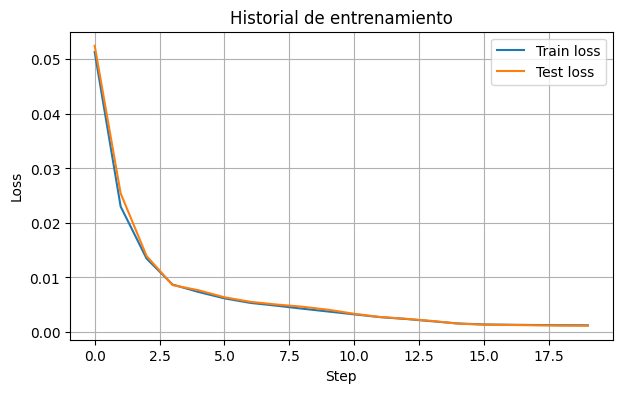

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(results["train_loss"], label="Train loss")
plt.plot(results["test_loss"], label="Test loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Historial de entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

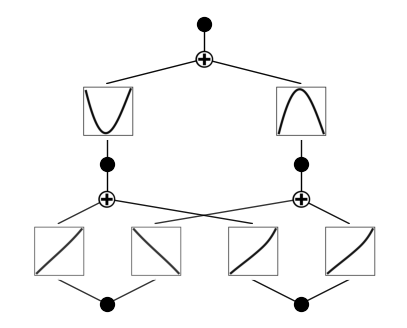

In [11]:
# =====================================================
# 6. Visualizar la red aprendida
# =====================================================
import os

# Carpeta donde quieres guardar las figuras
plot_folder = "./figuras_model_plot"
os.makedirs(plot_folder, exist_ok=True)

# Guardar/generar el plot del modelo
model.plot(folder=plot_folder)

plt.show()

En una KAN, cada conexión no es solo un número. Cada conexión tiene una función aprendida. Esa función se construye con una malla (grid), coeficientes (coef) y escalas (scale_base, scale_sp). La máscara (mask) indica si la conexión está activa o no.

| Elemento     |                  Tamaño | Cómo interpreto el tamaño                                                                                | Qué significa                                                                   |
| ------------ | ----------------------: | -------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| `grid`       |   `torch.Size([2, 10])` | `2` = número de entradas de la capa. `10` = puntos de la malla extendida para cada entrada.  La razón es que internamente la spline necesita una malla extendida. De forma práctica: numero de puntos guardados en grid=grid+2k+1 En tu caso: 3+2(3)+1=10            | Malla donde se definen las splines. Hay una malla para (x_1) y otra para (x_2). |
| `coef`       | `torch.Size([2, 2, 6])` | Primer `2` = entradas. Segundo `2` = nodos de salida de la capa. `6` = coeficientes spline por conexión (grid+k). | Coeficientes aprendidos que definen la forma de cada spline.                    |
| `mask`       |    `torch.Size([2, 2])` | Primer `2` = entradas. Segundo `2` = nodos de salida.                                                    | Indica qué conexiones están activas o apagadas.                                 |
| `scale_base` |    `torch.Size([2, 2])` | Primer `2` = entradas. Segundo `2` = nodos de salida.                                                    | Escala de la función base en cada conexión.                                     |
| `scale_sp`   |    `torch.Size([2, 2])` | Primer `2` = entradas. Segundo `2` = nodos de salida.                                                    | Escala de la parte spline en cada conexión.                                     |



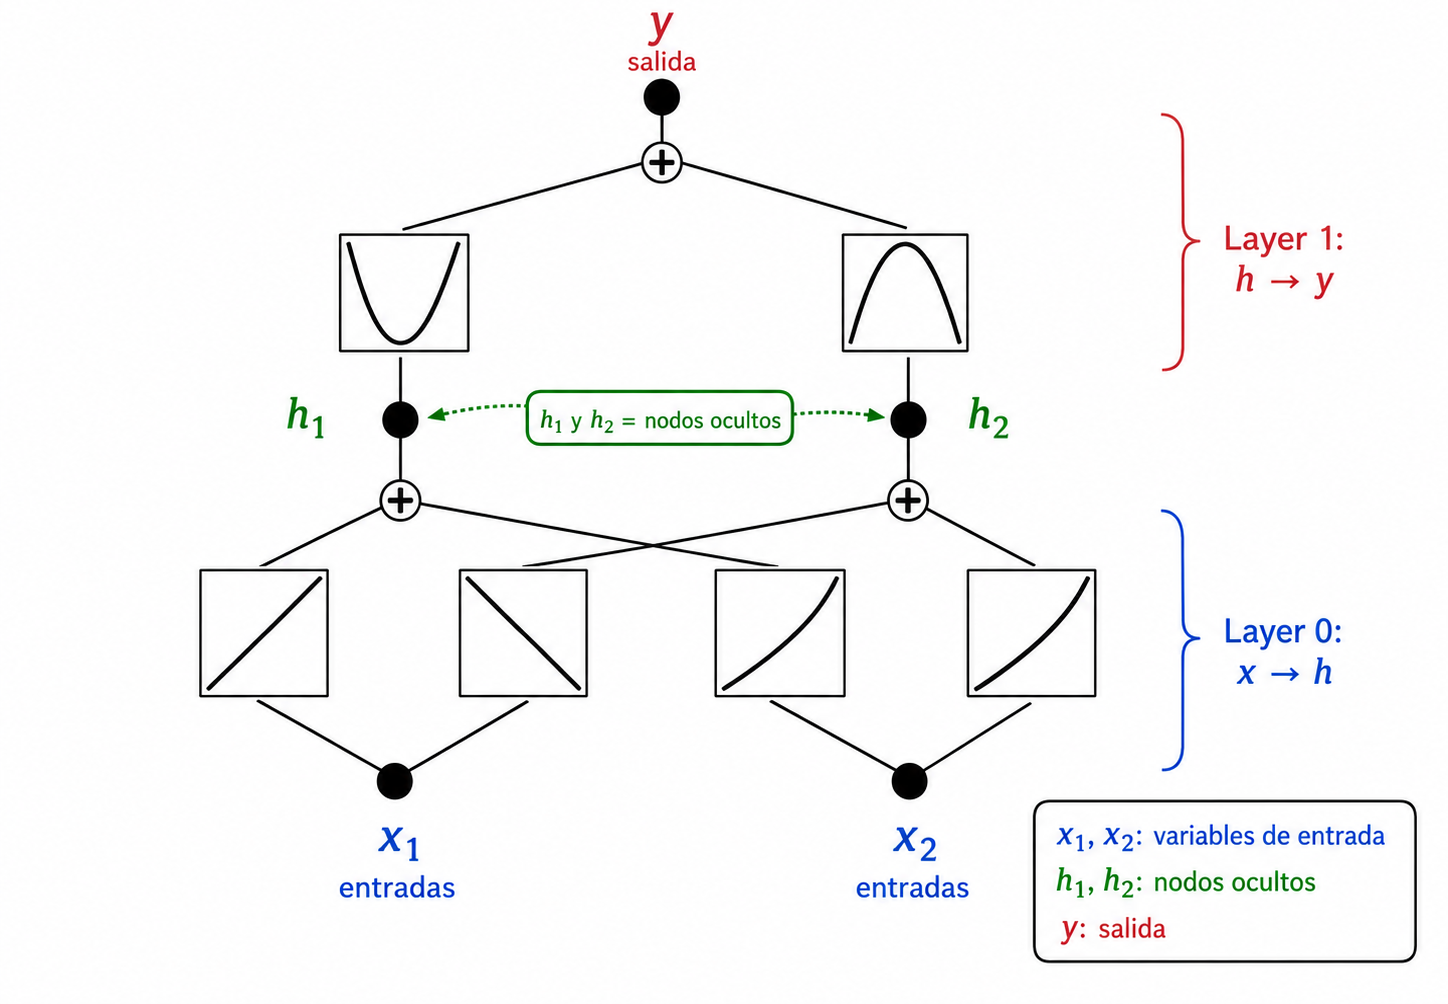

In [12]:
print(model.width_out)
print("-" * 90)
print(model.act_fun)
print("-" * 90)
layer0 = model.act_fun[0]
state = layer0.state_dict()

for key, value in state.items():
    print(key, value.shape)

print("-" * 90)

layer1 = model.act_fun[1]
state = layer1.state_dict()

for key, value in state.items():
    print(key, value.shape)

print("-" * 90)

[2, 2, 1]
------------------------------------------------------------------------------------------
ModuleList(
  (0-1): 2 x KANLayer(
    (base_fun): SiLU()
  )
)
------------------------------------------------------------------------------------------
grid torch.Size([2, 10])
coef torch.Size([2, 2, 6])
mask torch.Size([2, 2])
scale_base torch.Size([2, 2])
scale_sp torch.Size([2, 2])
------------------------------------------------------------------------------------------
grid torch.Size([2, 10])
coef torch.Size([2, 1, 6])
mask torch.Size([2, 1])
scale_base torch.Size([2, 1])
scale_sp torch.Size([2, 1])
------------------------------------------------------------------------------------------


## ¿Qué aprende una KAN en cada conexión?

En una red neuronal clásica, cada conexión suele tener un **peso escalar**.   En cambio, en una **KAN** (*Kolmogorov-Arnold Network*), cada conexión tiene una **función de activación aprendible**.

Esta función se puede escribir como:

$$
\phi(x)=w_b b(x)+w_s \operatorname{spline}(x)
$$

donde:

- $\phi(x)$ es la función de activación completa de una conexión.
- $b(x)$ es una función base.
- $\operatorname{spline}(x)$ es la parte flexible aprendida.
- $w_b$ y $w_s$ son pesos entrenables que controlan la importancia de cada parte.

---

## Parte 1: función base SiLU

En la implementaciones de KAN, la función base se define como:

$$
b(x)=\operatorname{silu}(x)=\frac{x}{1+e^{-x}}
$$

Esta parte funciona como una activación base o residual.   No se aprende desde cero como una spline, sino que ya tiene una forma definida.

Su contribución dentro de la activación es:

$$
w_b b(x)
$$

o, sustituyendo $b(x)$:

$$
w_b \operatorname{silu}(x)
$$

---

## Parte 2: spline aprendida

La parte flexible de la activación es una spline.  
Esta spline se construye como una combinación lineal de funciones base B-spline:
$$
\operatorname{spline}(x)=\sum_i c_i B_i(x)
$$

donde:

- $B_i(x)$ son las funciones base B-spline.
- $c_i$ son coeficientes entrenables.
- La suma de estas funciones permite formar curvas flexibles.

Su contribución dentro de la activación es:

$$
w_s \operatorname{spline}(x)
$$

o, escribiéndola completa:

$$
w_s \sum_i c_i B_i(x)
$$

---

## Activación completa

Por lo tanto, la activación completa en una conexión de una KAN puede escribirse como:

$$
\phi(x)
=
\underbrace{w_b \operatorname{silu}(x)}_{\text{parte base o residual}}
+
\underbrace{w_s \sum_i c_i B_i(x)}_{\text{parte spline aprendida}}
$$

---

## Interpretación intuitiva

La spline no tiene dos partes.  
Más bien, la **función de activación completa** tiene dos componentes:

1. Una parte base, normalmente SiLU.
2. Una parte aprendida, construida con B-splines.

En palabras simples:

* En una KAN, cada conexión no aprende únicamente un peso como en una red neuronal clásica.  
* En su lugar, aprende una función $\phi(x)$.  
* Esta función se forma sumando una activación base, como SiLU, y una spline aprendida mediante una combinación lineal de B-splines.

Esto permite que cada conexión tenga una forma flexible y adaptable a los datos.

In [13]:
import os
import torch
import matplotlib.pyplot as plt
from kan.spline import coef2curve

# ============================================================
# FUNCIÓN 1:
# Graficar las splines de una capa de la KAN
# ============================================================

def plot_layer_splines_full(
    model,
    layer_idx,
    input_names=None,
    output_names=None,
    x_min=-1,
    x_max=1,
    n_points=300,
    device=None,
    save_folder=None
):
    """
    Grafica todas las funciones aprendidas en una capa de una KAN.

    Para cada conexión entrada_i -> salida_j, la KAN aprende una función:

        phi_ij(x) = scale_base_ij * base_fun(x)
                    + scale_sp_ij * spline_ij(x)

    Esta función grafica:
    1. Solo la spline aprendida.
    2. Solo la función base escalada.
    3. La función completa de la conexión.

    Parámetros
    ----------
    model : KAN
        Modelo KAN ya entrenado.

    layer_idx : int
        Índice de la capa:
        - 0: primera capa, por ejemplo x -> h
        - 1: segunda capa, por ejemplo h -> y

    input_names : list[str]
        Nombres de las entradas de la capa.
        Ejemplo para layer0: ["x1", "x2"]
        Ejemplo para layer1: ["h1", "h2"]

    output_names : list[str]
        Nombres de las salidas de la capa.
        Ejemplo para layer0: ["h1", "h2"]
        Ejemplo para layer1: ["y"]

    x_min, x_max : float
        Rango donde se evaluará cada función 1D.

    n_points : int
        Número de puntos usados para dibujar cada curva.

    device : torch.device
        CPU o GPU.

    save_folder : str or None
        Si no es None, guarda las figuras en esa carpeta.
    """

    # --------------------------------------------------------
    # 1. Detectar dispositivo
    # --------------------------------------------------------
    # Si no se pasa device, usamos el dispositivo donde vive el modelo.
    if device is None:
        device = next(model.parameters()).device

    # --------------------------------------------------------
    # 2. Entrar a una capa específica del modelo
    # --------------------------------------------------------
    # model.act_fun guarda las funciones aprendibles por capa.
    #
    # En una KAN width=[2,2,1]:
    #   model.act_fun[0] corresponde a x -> h
    #   model.act_fun[1] corresponde a h -> y
    layer = model.act_fun[layer_idx]

    # --------------------------------------------------------
    # 3. Extraer elementos internos de la capa
    # --------------------------------------------------------
    # grid:
    #   malla donde se definen las splines.
    #
    # coef:
    #   coeficientes aprendidos de las splines.
    #
    # scale_base:
    #   escala de la función base por conexión.
    #
    # scale_sp:
    #   escala de la spline por conexión.
    #
    # mask:
    #   indica si una conexión está activa o no.
    grid = layer.grid
    coef = layer.coef
    scale_base = layer.scale_base
    scale_sp = layer.scale_sp

    # Algunas versiones tienen mask.
    # Si existe, la usamos. Si no, asumimos que todo está activo.
    mask = layer.mask if hasattr(layer, "mask") else None

    # --------------------------------------------------------
    # 4. Detectar dimensiones de la capa
    # --------------------------------------------------------
    # coef normalmente tiene forma:
    #   [in_dim, out_dim, n_coef]
    #
    # Por ejemplo, en layer0 de width=[2,2,1]:
    #   coef.shape = [2, 2, 6]
    #
    # Eso significa:
    #   2 entradas
    #   2 salidas
    #   6 coeficientes por spline
    in_dim = coef.shape[0]
    out_dim = coef.shape[1]

    print("=" * 70)
    print(f"Capa {layer_idx}")
    print("=" * 70)
    print("grid.shape       :", tuple(grid.shape))
    print("coef.shape       :", tuple(coef.shape))
    print("scale_base.shape :", tuple(scale_base.shape))
    print("scale_sp.shape   :", tuple(scale_sp.shape))
    if mask is not None:
        print("mask.shape       :", tuple(mask.shape))

    # --------------------------------------------------------
    # 5. Crear puntos para evaluar las curvas
    # --------------------------------------------------------
    # Cada spline es una función 1D.
    # Generamos valores entre x_min y x_max.
    x_eval = torch.linspace(x_min, x_max, n_points).reshape(-1, 1).to(device)

    # coef2curve espera una matriz con tantas columnas como entradas tenga la capa.
    #
    # Si la capa tiene in_dim=2, necesitamos algo de forma:
    #   [n_points, 2]
    #
    # Repetimos la misma columna porque queremos evaluar cada spline
    # en el mismo rango de valores.
    x_eval_layer = x_eval.repeat(1, in_dim)

    # --------------------------------------------------------
    # 6. Evaluar SOLO la parte spline
    # --------------------------------------------------------
    # coef2curve toma:
    #   x_eval_layer: puntos donde evaluar
    #   grid: malla de la spline
    #   coef: coeficientes aprendidos
    #   model.k: grado de la spline
    #
    # Devuelve algo de forma:
    #   [n_points, in_dim, out_dim]
    #
    # Entonces:
    #   y_spline[:, i, j]
    # es la spline de la conexión entrada_i -> salida_j.
    y_spline = coef2curve(
        x_eval_layer,
        grid,
        coef,
        model.k,
        device=device
    )

    # --------------------------------------------------------
    # 7. Evaluar la función base
    # --------------------------------------------------------
    # En pykan, cada conexión suele tener una parte base.
    # Esa función base normalmente es SiLU.
    #
    # La función completa de una conexión se parece a:
    #
    #   scale_base * base_fun(x) + scale_sp * spline(x)
    #
    # Aquí evaluamos base_fun en los mismos puntos.
    base_eval = layer.base_fun(x_eval_layer)

    # --------------------------------------------------------
    # 8. Crear nombres por defecto si no se pasan
    # --------------------------------------------------------
    if input_names is None:
        input_names = [f"input_{i+1}" for i in range(in_dim)]

    if output_names is None:
        output_names = [f"output_{j+1}" for j in range(out_dim)]

    # --------------------------------------------------------
    # 9. Carpeta para guardar figuras
    # --------------------------------------------------------
    if save_folder is not None:
        os.makedirs(save_folder, exist_ok=True)

    # --------------------------------------------------------
    # 10. Graficar cada conexión
    # --------------------------------------------------------
    for i in range(in_dim):
        for j in range(out_dim):

            # -----------------------------------------------
            # Spline aprendida de la conexión i -> j
            # -----------------------------------------------
            spline_ij = y_spline[:, i, j]

            # -----------------------------------------------
            # Función base de la entrada i
            # -----------------------------------------------
            base_i = base_eval[:, i]

            # -----------------------------------------------
            # Escalas de esta conexión
            # -----------------------------------------------
            sb = scale_base[i, j]
            ss = scale_sp[i, j]

            # -----------------------------------------------
            # Función completa de la conexión
            # -----------------------------------------------
            # Esta es la que normalmente se parece más
            # a lo que aparece en model.plot().
            full_ij = sb * base_i + ss * spline_ij

            # -----------------------------------------------
            # Si hay máscara, la usamos para saber si está activa
            # -----------------------------------------------
            if mask is not None:
                mask_ij = mask[i, j].detach().cpu().item()
            else:
                mask_ij = 1.0

            # -----------------------------------------------
            # Convertir a numpy para graficar
            # -----------------------------------------------
            x_np = x_eval.detach().cpu().numpy()
            spline_np = spline_ij.detach().cpu().numpy()
            base_np = (sb * base_i).detach().cpu().numpy()
            full_np = full_ij.detach().cpu().numpy()

            # -----------------------------------------------
            # Graficar
            # -----------------------------------------------
            plt.figure(figsize=(8, 5))

            plt.plot(x_np, spline_np, label="Solo spline aprendida")
            plt.plot(x_np, base_np, label="Parte base escalada")
            plt.plot(x_np, full_np, label="Función completa", linewidth=2)

            plt.xlabel(input_names[i])
            plt.ylabel("Valor")
            plt.title(
                f"Capa {layer_idx}: {input_names[i]} → {output_names[j]} "
                f"| mask={mask_ij:.2f}"
            )
            plt.grid(True)
            plt.legend()
            plt.tight_layout()

            # -----------------------------------------------
            # Guardar o mostrar
            # -----------------------------------------------
            if save_folder is not None:
                filename = f"layer{layer_idx}_{input_names[i]}_to_{output_names[j]}.png"
                path = os.path.join(save_folder, filename)
                plt.savefig(path, dpi=300, bbox_inches="tight")
                print("Figura guardada:", path)

            plt.show()

Capa 0
grid.shape       : (2, 10)
coef.shape       : (2, 2, 6)
scale_base.shape : (2, 2)
scale_sp.shape   : (2, 2)
mask.shape       : (2, 2)
Figura guardada: ./splines_kan/layer0\layer0_x1_to_h1.png


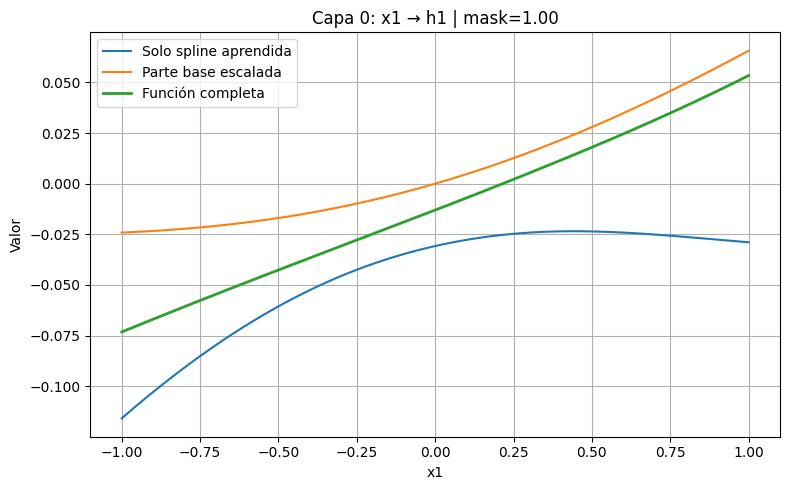

Figura guardada: ./splines_kan/layer0\layer0_x1_to_h2.png


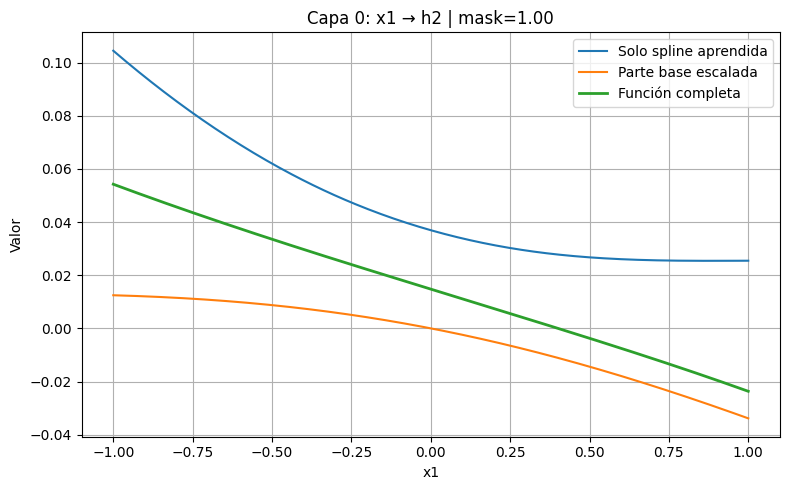

Figura guardada: ./splines_kan/layer0\layer0_x2_to_h1.png


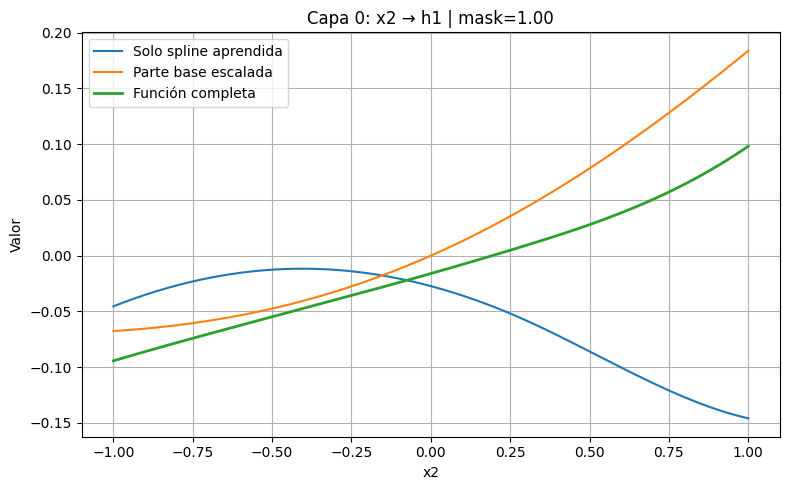

Figura guardada: ./splines_kan/layer0\layer0_x2_to_h2.png


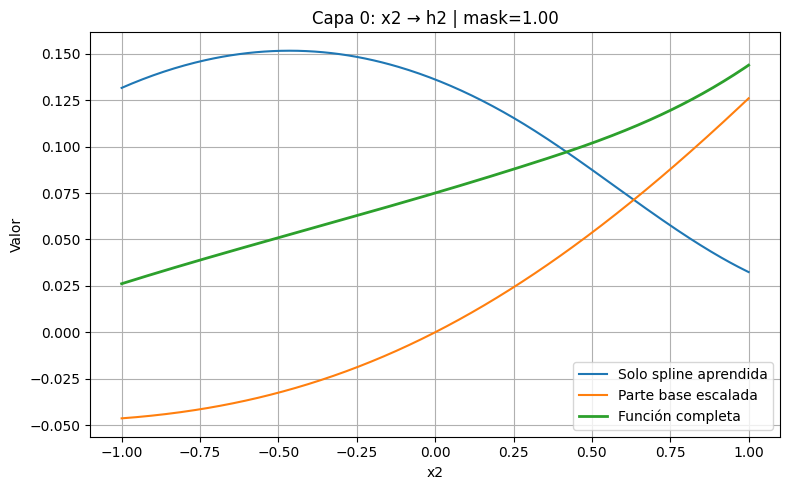

In [14]:
plot_layer_splines_full(
    model=model,
    layer_idx=0,
    input_names=["x1", "x2"],
    output_names=["h1", "h2"],
    x_min=-1,
    x_max=1,
    n_points=300,
    device=device,
    save_folder="./splines_kan/layer0"
)

Capa 1
grid.shape       : (2, 10)
coef.shape       : (2, 1, 6)
scale_base.shape : (2, 1)
scale_sp.shape   : (2, 1)
mask.shape       : (2, 1)
Figura guardada: ./splines_kan/layer1\layer1_h1_to_y.png


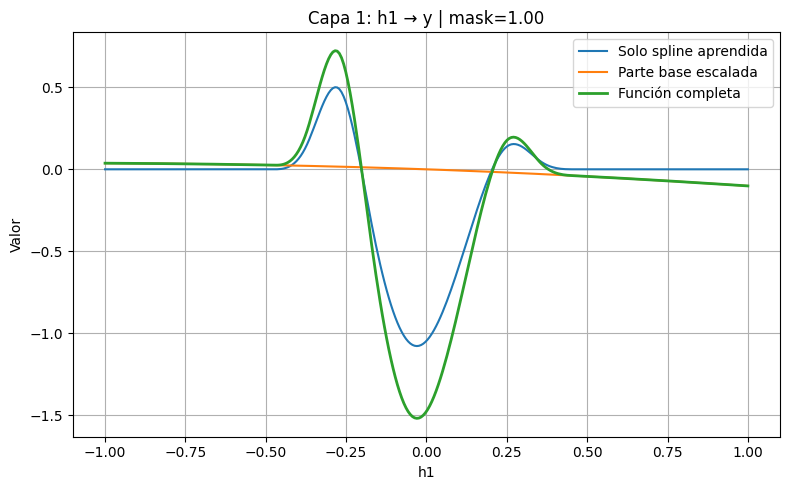

Figura guardada: ./splines_kan/layer1\layer1_h2_to_y.png


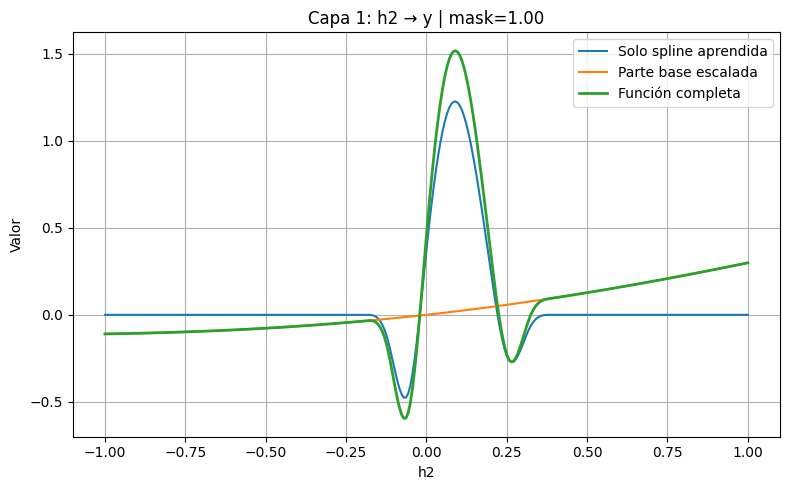

In [15]:
plot_layer_splines_full(
    model=model,
    layer_idx=1,
    input_names=["h1", "h2"],
    output_names=["y"],
    x_min=-1,
    x_max=1,
    n_points=300,
    device=device,
    save_folder="./splines_kan/layer1"
)

In [16]:
from kan.spline import coef2curve

def plot_one_spline(
    model,
    layer_idx=0,
    input_idx=0,
    output_idx=0,
    X=None,
    input_name=None,
    output_name=None,
    n_points=300,
    device=None
):
    """
    Grafica una función aprendida por una conexión específica de una KAN.

    En una KAN, cada conexión entre una entrada y una salida no es solo un peso,
    sino una función aprendible. Esta función está formada por:

        función completa = parte base + parte spline

    donde:

        parte base   = scale_base * SiLU(x)
        parte spline = scale_sp * spline(x)

    Parámetros
    ----------
    model : modelo KAN entrenado
        Es el modelo del cual queremos extraer la spline aprendida.

    layer_idx : int
        Índice de la capa que queremos analizar.
        Por ejemplo:
            0 = primera capa
            1 = segunda capa
    input_idx : int
        Índice de la entrada dentro de esa capa.
        Por ejemplo, si la capa recibe [x1, x2], entonces:
            0 = x1
            1 = x2

    output_idx : int
        Índice del nodo de salida dentro de esa capa.
        Por ejemplo, si la capa tiene dos nodos de salida [h1, h2]:
            0 = h1
            1 = h2

    X : tensor, opcional
        Datos de entrada. Sirve para definir el rango real de valores
        donde se evaluará la spline.

    input_name : str, opcional
        Nombre de la variable de entrada para mostrar en la gráfica.

    output_name : str, opcional
        Nombre del nodo o salida para mostrar en la gráfica.

    n_points : int
        Número de puntos usados para dibujar la curva.
        Entre más puntos, más suave se ve la gráfica.

    device : str o torch.device, opcional
        Dispositivo donde está el modelo: "cpu", "cuda" o "mps".
    """

    # ------------------------------------------------------------
    # 1. Determinar el dispositivo donde está el modelo
    # ------------------------------------------------------------

    # Si no se indicó explícitamente el dispositivo, el código lo detecta
    # automáticamente revisando dónde están guardados los parámetros del modelo.
    #
    # Esto es importante porque en PyTorch no puedes mezclar tensores en CPU
    # con tensores en GPU o MPS. Todo debe estar en el mismo dispositivo.
    #
    # Por ejemplo:
    #   - si el modelo está en CPU, x_eval también debe estar en CPU.
    #   - si el modelo está en CUDA, x_eval también debe estar en CUDA.
    #   - si el modelo está en MPS, x_eval también debería estar en MPS.
    #
    # next(model.parameters()) toma el primer parámetro del modelo.
    # .device obtiene el dispositivo donde está ese parámetro.
    if device is None:
        device = next(model.parameters()).device


    # ------------------------------------------------------------
    # 2. Seleccionar la capa KAN que queremos analizar
    # ------------------------------------------------------------

    # model.act_fun contiene las capas KAN del modelo.
    #
    # Por ejemplo, si el modelo es:
    #
    #     KAN(width=[2, 2, 1])
    #
    # entonces existen dos transformaciones:
    #
    #     capa 0: 2 entradas -> 2 nodos ocultos
    #     capa 1: 2 nodos ocultos -> 1 salida
    #
    # model.act_fun[0] selecciona la primera capa.
    # model.act_fun[1] selecciona la segunda capa.
    layer = model.act_fun[layer_idx]


    # ------------------------------------------------------------
    # 3. Extraer los componentes internos de esa capa
    # ------------------------------------------------------------

    # grid contiene los puntos sobre los cuales se construyen las splines.
    #
    # Una spline no se define como una sola fórmula global,
    # sino como una curva formada por partes. El grid ayuda a definir
    # esas regiones o intervalos donde actúan las funciones base.
    grid = layer.grid

    # coef contiene los coeficientes aprendidos de las splines.
    #
    # Estos coeficientes son parámetros entrenables.
    # Durante el entrenamiento, la KAN modifica estos valores para cambiar
    # la forma de la curva aprendida.
    #
    # Conceptualmente:
    #
    #     coeficientes diferentes -> spline con forma diferente
    #
    # Por eso son importantes para interpretar qué forma aprendió la conexión.
    coef = layer.coef

    # scale_base controla cuánto aporta la parte base fija.
    #
    # En pykan, la parte base suele ser SiLU.
    # Esta parte funciona como una activación suave inicial o de apoyo.
    #
    # No es la spline; es una función fija que también puede contribuir
    # a la función total de la conexión.
    scale_base = layer.scale_base

    # scale_sp controla cuánto aporta la spline aprendida.
    #
    # Si este valor es grande, la spline pesa mucho en la función final.
    # Si es pequeño, la spline aporta poco.
    #
    # Entonces la KAN no solo aprende la forma de la spline mediante coef,
    # también aprende qué tanto usar esa spline mediante scale_sp.
    scale_sp = layer.scale_sp


    # ------------------------------------------------------------
    # 4. Obtener las dimensiones de la capa
    # ------------------------------------------------------------

    # coef normalmente tiene forma:
    #
    #     [número de entradas, número de salidas, número de coeficientes]
    #
    # Por ejemplo, si una capa conecta 2 entradas con 2 salidas:
    #
    #     coef.shape = [2, 2, 6]
    #
    # Eso significa:
    #
    #     2 entradas
    #     2 salidas
    #     6 coeficientes para cada spline
    #
    # in_dim guarda cuántas entradas tiene esta capa.
    in_dim = coef.shape[0]

    # out_dim guarda cuántas salidas tiene esta capa.
    out_dim = coef.shape[1]


    # ------------------------------------------------------------
    # 5. Revisar que los índices elegidos sean válidos
    # ------------------------------------------------------------

    # Si la capa tiene in_dim entradas, los índices válidos son:
    #
    #     0, 1, ..., in_dim - 1
    #
    # Por ejemplo, si in_dim = 2, los índices válidos son:
    #
    #     input_idx = 0
    #     input_idx = 1
    #
    # Si alguien pone input_idx = 2, eso ya no existe.
    if input_idx >= in_dim:
        raise ValueError(f"input_idx debe ser menor que {in_dim}")

    # Lo mismo para las salidas.
    #
    # Si out_dim = 2, los índices válidos son:
    #
    #     output_idx = 0
    #     output_idx = 1
    #
    # Si out_dim = 1, solo existe:
    #
    #     output_idx = 0
    if output_idx >= out_dim:
        raise ValueError(f"output_idx debe ser menor que {out_dim}")


    # ------------------------------------------------------------
    # 6. Definir el rango donde se va a graficar la función
    # ------------------------------------------------------------

    # La función aprendida debe evaluarse en un intervalo de valores.
    #
    # Por ejemplo, si queremos graficar una función de x, necesitamos
    # decidir desde qué valor hasta qué valor se dibuja:
    #
    #     x_min <= x <= x_max
    #
    # Si pasamos X, usamos el rango real de los datos.
    #
    # Esto es recomendable porque así la gráfica se interpreta en el dominio
    # donde el modelo realmente vio información durante el entrenamiento.
    if X is not None:

        # Toma el valor mínimo de la variable input_idx en los datos X.
        #
        # Si input_idx = 0, toma el mínimo de la primera variable.
        # Si input_idx = 1, toma el mínimo de la segunda variable.
        #
        # .item() convierte el resultado de tensor a número de Python.
        x_min = X[:, input_idx].min().item()

        # Toma el valor máximo de esa misma variable.
        x_max = X[:, input_idx].max().item()

    else:

        # Si no se pasan datos X, se usa un rango genérico de -1 a 1.
        #
        # Esto suele funcionar si los datos fueron normalizados o escalados
        # a un intervalo parecido.
        #
        # Pero si tus datos no están en ese rango, la gráfica podría mostrar
        # una zona que no corresponde al rango real de entrenamiento.
        x_min = -1
        x_max = 1


    # ------------------------------------------------------------
    # 7. Crear puntos donde se evaluará la función
    # ------------------------------------------------------------

    # torch.linspace crea una secuencia de valores igualmente espaciados.
    #
    # Por ejemplo:
    #
    #     torch.linspace(-1, 1, 5)
    #
    # produce algo parecido a:
    #
    #     [-1.0, -0.5, 0.0, 0.5, 1.0]
    #
    # Aquí usamos n_points puntos, por defecto 300.
    #
    # Entre más puntos, más suave se verá la curva.
    x_eval = torch.linspace(x_min, x_max, n_points).reshape(-1, 1).to(device)

    # reshape(-1, 1) convierte el vector en una columna.
    #
    # Sin reshape, x_eval tendría forma:
    #
    #     [300]
    #
    # Después de reshape:
    #
    #     [300, 1]
    #
    # Esto es necesario porque las funciones de KAN esperan entradas
    # en forma de matriz: filas = observaciones, columnas = variables.


    # ------------------------------------------------------------
    # 8. Adaptar x_eval a la forma esperada por coef2curve
    # ------------------------------------------------------------

    # Aunque queremos graficar una sola entrada, coef2curve espera recibir
    # una matriz con tantas columnas como entradas tenga la capa.
    #
    # Por ejemplo, si la capa tiene 2 entradas, espera algo con forma:
    #
    #     [n_points, 2]
    #
    # Pero x_eval tiene forma:
    #
    #     [n_points, 1]
    #
    # Entonces repetimos la columna para obtener:
    #
    #     [n_points, in_dim]
    #
    # Si in_dim = 2:
    #
    #     columna 1 = x_eval
    #     columna 2 = x_eval
    #
    # Esto no significa que estemos interpretando todas las variables reales.
    # Es solo una forma práctica de permitir que coef2curve calcule todas
    # las splines y luego nosotros seleccionamos la conexión que nos interesa.
    x_eval_layer = x_eval.repeat(1, in_dim)


    # ------------------------------------------------------------
    # 9. Evaluar la spline aprendida
    # ------------------------------------------------------------

    # coef2curve reconstruye las curvas spline a partir de:
    #
    #     x_eval_layer : puntos donde se evalúa la spline
    #     grid         : grid de la capa
    #     coef         : coeficientes aprendidos
    #     model.k      : grado de la spline
    #
    # El resultado y_spline contiene los valores de las splines para todas
    # las conexiones de la capa.
    #
    # Su forma típica es:
    #
    #     [n_points, in_dim, out_dim]
    #
    # Por ejemplo, si:
    #
    #     n_points = 300
    #     in_dim = 2
    #     out_dim = 2
    #
    # entonces:
    #
    #     y_spline.shape = [300, 2, 2]
    #
    # Eso significa:
    #
    #     300 puntos evaluados
    #     2 entradas
    #     2 salidas
    #
    # Es decir, contiene las cuatro splines:
    #
    #     entrada 0 -> salida 0
    #     entrada 0 -> salida 1
    #     entrada 1 -> salida 0
    #     entrada 1 -> salida 1
    y_spline = coef2curve(
        x_eval_layer,
        grid,
        coef,
        model.k,
        device=device
    )


    # ------------------------------------------------------------
    # 10. Evaluar la función base
    # ------------------------------------------------------------

    # Además de la spline, cada conexión tiene una parte base.
    #
    # Esa parte base se obtiene evaluando layer.base_fun.
    # En tu salida anterior se veía que la base_fun era SiLU().
    #
    # Entonces esta línea calcula:
    #
    #     SiLU(x)
    #
    # para los mismos puntos donde estamos evaluando la spline.
    base_eval = layer.base_fun(x_eval_layer)


    # ------------------------------------------------------------
    # 11. Seleccionar la conexión específica
    # ------------------------------------------------------------

    # y_spline contiene las splines de todas las conexiones de la capa.
    #
    # Pero nosotros solo queremos una conexión:
    #
    #     input_idx -> output_idx
    #
    # Por eso usamos:
    #
    #     y_spline[:, input_idx, output_idx]
    #
    # Los dos puntos ":" significan:
    #
    #     toma todos los puntos evaluados
    #
    # Entonces spline será un vector con longitud n_points.
    spline = y_spline[:, input_idx, output_idx]

    # base_eval contiene la función base evaluada para todas las entradas.
    #
    # Aquí seleccionamos la parte base correspondiente a la entrada input_idx.
    #
    # Nota:
    # La parte base todavía no está multiplicada por scale_base.
    base = base_eval[:, input_idx]


    # ------------------------------------------------------------
    # 12. Tomar los factores de escala de esa conexión
    # ------------------------------------------------------------

    # scale_base tiene un valor por conexión.
    #
    # Si la conexión es:
    #
    #     input_idx -> output_idx
    #
    # entonces el factor correspondiente es:
    #
    #     scale_base[input_idx, output_idx]
    #
    # Este valor dice qué tanto se usa la parte base en esa conexión.
    sb = scale_base[input_idx, output_idx]

    # scale_sp también tiene un valor por conexión.
    #
    # Este valor dice qué tanto se usa la spline aprendida en esa conexión.
    ss = scale_sp[input_idx, output_idx]


    # ------------------------------------------------------------
    # 13. Construir la función completa de la conexión
    # ------------------------------------------------------------

    # La función completa de la conexión se calcula como:
    #
    #     full_function = scale_base * base_fun(x)
    #                     + scale_sp * spline(x)
    #
    # En este código:
    #
    #     sb * base     = parte base escalada
    #     ss * spline   = parte spline escalada
    #
    # Entonces full_function representa la función real que está usando
    # la KAN para transformar esa entrada hacia ese nodo de salida.
    full_function = sb * base + ss * spline


    # ------------------------------------------------------------
    # 14. Crear nombres automáticos si no se proporcionaron
    # ------------------------------------------------------------

    # Si el usuario no da un nombre para la variable de entrada,
    # se usa un nombre genérico.
    #
    # Por ejemplo:
    #
    #     entrada 0
    #     entrada 1
    if input_name is None:
        input_name = f"entrada {input_idx}"

    # Lo mismo para el nodo de salida.
    #
    # Por ejemplo:
    #
    #     salida 0
    #     salida 1
    if output_name is None:
        output_name = f"salida {output_idx}"


    # ------------------------------------------------------------
    # 15. Convertir tensores de PyTorch a arreglos de NumPy
    # ------------------------------------------------------------

    # Matplotlib trabaja más cómodamente con arreglos de NumPy.
    #
    # Por eso convertimos los tensores antes de graficar.
    #
    # detach() separa el tensor del grafo de cálculo de PyTorch.
    # Esto es importante porque no queremos calcular gradientes aquí.
    #
    # cpu() mueve el tensor a CPU.
    # Esto es necesario si el modelo estaba en GPU, porque matplotlib
    # no puede graficar directamente tensores en CUDA o MPS.
    #
    # numpy() convierte el tensor a arreglo de NumPy.
    x_np = x_eval.detach().cpu().numpy()

    # Convierte la spline sin escalar a NumPy.
    #
    # Esta curva representa la forma aprendida por la spline antes de
    # multiplicarla por scale_sp.
    spline_np = spline.detach().cpu().numpy()

    # Convierte la parte base escalada.
    #
    # Aquí sí se multiplica por sb porque nos interesa ver la contribución
    # real de la parte base dentro de la función completa.
    base_np = (sb * base).detach().cpu().numpy()

    # Convierte la función completa a NumPy.
    #
    # Esta es la curva más importante si queremos saber qué transformación
    # está aplicando realmente la conexión.
    full_np = full_function.detach().cpu().numpy()


    # ------------------------------------------------------------
    # 16. Graficar la conexión aprendida
    # ------------------------------------------------------------

    # Crea una figura de 7 pulgadas de ancho por 5 de alto.
    plt.figure(figsize=(7, 5))

    # Grafica la spline aprendida sin escalar.
    #
    # Esta línea muestra la forma de la spline construida a partir de
    # los coeficientes aprendidos.
    plt.plot(x_np, spline_np, label="Spline aprendida")

    # Grafica la parte base escalada.
    #
    # Esto muestra cuánto contribuye la función base fija, por ejemplo SiLU.
    plt.plot(x_np, base_np, label="Parte base")

    # Grafica la función completa.
    #
    # Esta curva es la suma de:
    #
    #     parte base escalada + spline escalada
    #
    # Es la transformación final que realmente usa la conexión.
    #
    # linewidth=2 hace que esta curva se vea más gruesa para destacarla.
    plt.plot(x_np, full_np, label="Función completa", linewidth=2)

    # Nombre del eje horizontal.
    #
    # Normalmente será el nombre de la variable de entrada,
    # por ejemplo "NDVI", "NDBI", "distancia a calles", etc.
    plt.xlabel(input_name)

    # Nombre del eje vertical.
    #
    # No es una probabilidad directamente.
    # Es el valor de la función aprendida por esa conexión.
    plt.ylabel("Valor de la función")

    # Título de la gráfica.
    #
    # Indica qué capa y qué conexión se están mostrando.
    plt.title(f"Capa {layer_idx}: {input_name} → {output_name}")

    # Agrega una cuadrícula para facilitar la lectura.
    plt.grid(True)

    # Muestra la leyenda.
    plt.legend()

    # Ajusta los márgenes para que no se corten etiquetas o títulos.
    plt.tight_layout()

    # Muestra la figura.
    plt.show()

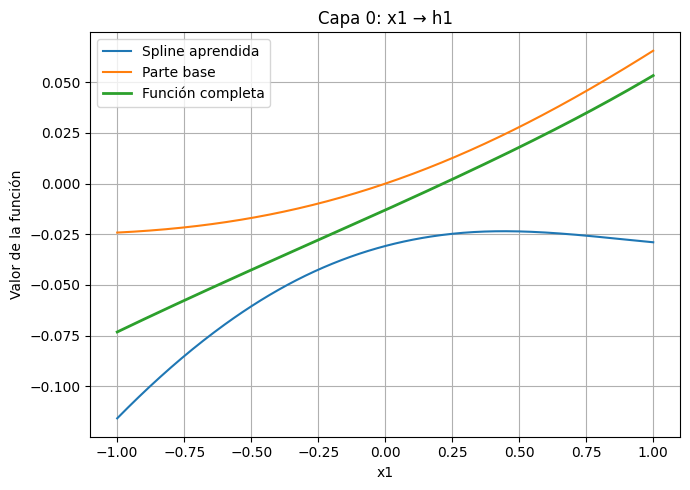

In [17]:
plot_one_spline(
    model,
    layer_idx=0,
    input_idx=0,
    output_idx=0,
    X=dataset["train_input"],
    input_name="x1",
    output_name="h1"
)

In [18]:
model = KAN(
    width=[2, 5, 1],
    grid=5,
    k=3,
    seed=1,
    device=device,
    ckpt_path="./salidas_kan/checkpoints_poda"
)

checkpoint directory created: ./salidas_kan/checkpoints_poda
saving model version 0.0


# Regularización en KAN: ¿esta parte explica `lamb`?

Sí. Esta sección explica la técnica de **sparsification**, es decir, cómo hacer que una KAN use menos conexiones o funciones activas.

La idea central es:

* En una MLP se puede aplicar regularización L1 sobre pesos lineales.  
* Pero en una KAN no hay un peso lineal simple por conexión; cada conexión tiene una función aprendible \(\phi\).  
* Entonces la regularización se aplica sobre la magnitud de esas funciones de activación aprendidas.

---

## 1. En una MLP se regularizan pesos

En una red neuronal tradicional, una conexión tiene un peso:

$$
w_{ij}
$$

Entonces, con regularización L1, se penaliza:

$$
|w_{ij}|
$$

Esto empuja algunos pesos hacia cero.

---

## 2. En una KAN no hay un peso simple

En una KAN, una conexión no se representa solo con un peso, sino con una función aprendible:

$$
\phi_{ij}(x)
$$

Por eso el texto dice:

> “There is no linear weight in KANs.”

Es decir, en KAN ya no se penaliza solamente un peso $w$, sino una función completa $\phi$.

---

## 3. Norma L1 de una función de activación

La regularización define la norma L1 de una función de activación como:

$$
|\phi|_1
=
\frac{1}{N_p}
\sum_{s=1}^{N_p}
|\phi(x^{(s)})|
$$

Esto significa:

* Para medir qué tan importante es una función $\phi$, la evaluamos en varios puntos $x^{(s)}$, tomamos el valor absoluto de sus salidas y calculamos el promedio.

Si la función produce valores grandes, entonces:

$$
|\phi|_1
$$

será grande.

Si la función está casi apagada o cerca de cero, entonces:

$$
|\phi|_1 \approx 0
$$

---

## 4. Norma L1 de toda una capa KAN

Para una capa KAN $\Phi$, con $n_{in}$ entradas y $n_{out}$ salidas, se define:

$$
|\Phi|_1
=
\sum_{i=1}^{n_{in}}
\sum_{j=1}^{n_{out}}
|\phi_{i,j}|_1
$$

Esto significa:

* Sumamos la importancia de todas las funciones de activación de la capa.

Por ejemplo, si una capa es:

$
2 \rightarrow 5
$

entonces hay funciones como:

$$
\phi_{1,1},\phi_{1,2},\dots,\phi_{2,5}
$$

y se suma la magnitud de todas.

---

## 5. Regularización por entropía

Además de la norma L1, se define una regularización de entropía:

$$
S(\Phi)
=
-
\sum_{i=1}^{n_{in}}
\sum_{j=1}^{n_{out}}
\frac{|\phi_{i,j}|_1}{|\Phi|_1}
\log
\left(
\frac{|\phi_{i,j}|_1}{|\Phi|_1}
\right)
$$

Esta entropía mide cómo se reparte la importancia entre conexiones.

De manera intuitiva:

| Situación | Entropía |
|---|---|
| Muchas conexiones aportan de forma parecida | Alta |
| Pocas conexiones concentran la importancia | Baja |

Entonces, al regularizar con entropía, se busca evitar que muchas conexiones aporten al mismo tiempo. La red tiende a concentrar la importancia en menos conexiones.

---

## 6. Función de pérdida total

La función objetivo total queda como:

$$
\ell_{\text{total}}
=
\ell_{\text{pred}}
+
\lambda
\left(
\mu_1
\sum_{l=0}^{L-1}
|\Phi_l|_1
+
\mu_2
\sum_{l=0}^{L-1}
S(\Phi_l)
\right)
$$

Esta ecuación tiene dos partes principales:

$$
\ell_{\text{pred}}
$$

que representa el error de predicción, y:

$$
\lambda
\left(
\mu_1
\sum_{l=0}^{L-1}
|\Phi_l|_1
+
\mu_2
\sum_{l=0}^{L-1}
S(\Phi_l)
\right)
$$

que representa el castigo por complejidad.

---

## 7. ¿Qué es `lamb`?

En la ecuación aparece:

$$
\lambda
$$

En `pykan`, ese parámetro se usa como:

```python
lamb=0.01

# ¿Para qué sirve `lamb` en una KAN?
lamb ayuda a añadir sparsity o dispersión a la red.

El parámetro `lamb` controla qué tanto queremos que la KAN sea **simple** además de precisa.

Sin `lamb`, el modelo solo intenta:

$$
\text{predecir bien}
$$

Con `lamb`, el modelo intenta:

$$
\text{predecir bien, pero usando una red lo más simple posible}
$$

la pérdida se vuelve algo parecido a:

$$
L_{total} = L_{datos} + \lambda R
$$

Entonces:

$$
L_{total} = Error de prediccion + castigo por complejidad
$$

| Valor de `lamb` | Efecto esperado                                        |
| --------------: | ------------------------------------------------------ |
|           `0.0` | No castiga complejidad. La red puede quedar más densa. |
|         `0.001` | Regularización suave. Buena opción inicial.            |
|          `0.01` | Regularización moderada. Suele ayudar a la poda.       |
|          `0.05` | Regularización fuerte. Puede apagar muchas conexiones. |
|           `0.1` | Puede ser demasiado fuerte y afectar la predicción.    |


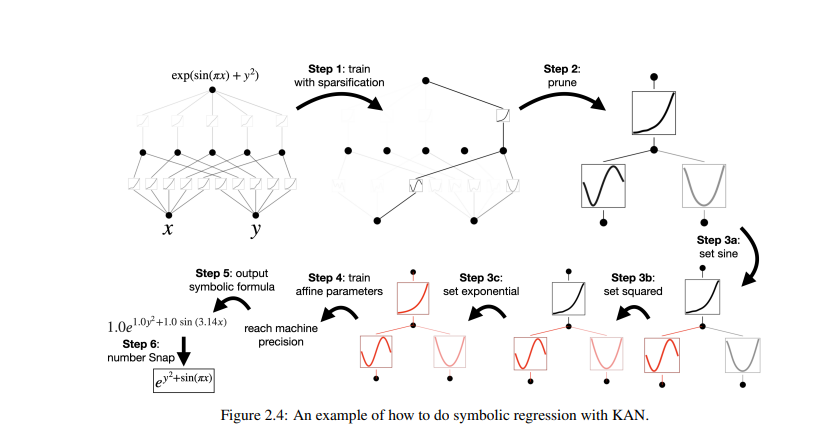

In [19]:
# ============================================================
# 2. Definir la función objetivo
# ============================================================
# Queremos aproximar:
#
#   f(x, y) = exp( sin(pi*x) + y^2 )
#
# x[:, [0]] -> x
# x[:, [1]] -> y
def f_target(x):
    x1 = x[:, [0]]
    x2 = x[:, [1]]
    return torch.exp(torch.sin(torch.pi * x1) + x2**2)

In [20]:
# ============================================================
# 3. Crear dataset sintético
# ============================================================
dataset = create_dataset(
    f_target,
    n_var=2,
    train_num=3000,
    test_num=1000,
    device=device
)

print("train_input:", dataset["train_input"].shape)
print("train_label:", dataset["train_label"].shape)
print("test_input :", dataset["test_input"].shape)
print("test_label :", dataset["test_label"].shape)

train_input: torch.Size([3000, 2])
train_label: torch.Size([3000, 1])
test_input : torch.Size([1000, 2])
test_label : torch.Size([1000, 1])


In [21]:
# ============================================================
# 4. Crear una arquitectura compatible con la descomposición
# ============================================================
# width=[2, 2, 1, 1] significa:
#
#   2 entradas  ->  2 nodos ocultos  ->  1 nodo intermedio  ->  1 salida
#
# La idea es:
#   - Primera capa: aprender componentes tipo sin(.) y x^2
#   - Segunda capa: sumar esas dos ramas
#   - Tercera capa: aplicar exp(.)

# Carpetas para guardar salidas
os.makedirs("./exp_kan/antes_poda", exist_ok=True)
os.makedirs("./exp_kan/despues_poda", exist_ok=True)
os.makedirs("./exp_kan/reentrenado", exist_ok=True)
os.makedirs("./exp_kan/checkpoints", exist_ok=True)

model = KAN(
    width=[2, 5, 1],
    grid=5,
    k=3,
    seed=1,
    device=device,
    ckpt_path="./exp_kan/checkpoints"
)

checkpoint directory created: ./exp_kan/checkpoints
saving model version 0.0


In [22]:
# ============================================================
# 5. Entrenamiento inicial con regularización
# ============================================================
# lamb ayuda a simplificar la red y facilita que algunas conexiones
# poco útiles se apaguen.
results = model.fit(
    dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001
)

| train_loss: 1.17e-02 | test_loss: 1.21e-02 | reg: 6.65e+00 | : 100%|█| 50/50 [00:43<00:00,  1.15it

saving model version 0.1



Modelo antes de poda


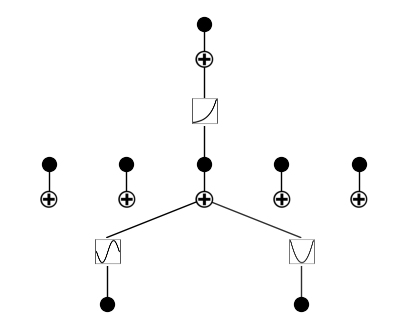

In [23]:
# ============================================================
# 6. Visualizar modelo antes de poda
# ============================================================
print("\nModelo antes de poda")
model.plot()
plt.savefig("./exp_kan/antes_poda/modelo_antes_poda.png", dpi=300, bbox_inches="tight")
plt.show()

saving model version 0.2

Modelo después de poda


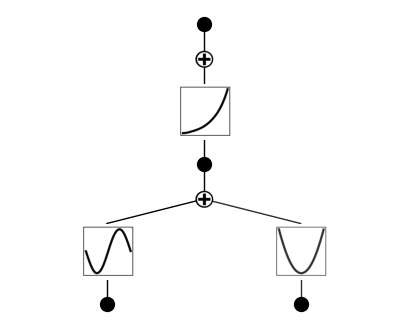

In [24]:
# ============================================================
# 7. Poda
# ============================================================
# prune() elimina nodos/conexiones que ya quedaron poco relevantes.
model_podado = model.prune()

print("\nModelo después de poda")
model_podado.plot()
plt.savefig("./exp_kan/antes_poda/modelo_antes_poda.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
print("Máscaras del modelo original:")
for i, layer in enumerate(model.act_fun):
    if hasattr(layer, "mask"):
        print(f"\nLayer {i}")
        print(layer.mask)

print("\nMáscaras del modelo podado:")
for i, layer in enumerate(model_podado.act_fun):
    if hasattr(layer, "mask"):
        print(f"\nLayer {i}")
        print(layer.mask)

Máscaras del modelo original:

Layer 0
Parameter containing:
tensor([[0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.]], device='cuda:0')

Layer 1
Parameter containing:
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [0.]], device='cuda:0')

Máscaras del modelo podado:

Layer 0
Parameter containing:
tensor([[1.],
        [1.]], device='cuda:0')

Layer 1
Parameter containing:
tensor([[1.]], device='cuda:0')


* layer      = número de capa
* input_id   = nodo de entrada de esa capa
* output_id  = nodo destino de esa capa
* funcion    = función simbólica

In [26]:
#fix_symbolic(layer, input_id, output_id, funcion)
model_podado.fix_symbolic(0, 0, 0, 'sin') # x1 -> h1
model_podado.fix_symbolic(0, 1, 0, 'x^2') # x2 -> h1
model_podado.fix_symbolic(1, 0, 0, 'exp') # h1 -> y

r2 is 0.999971866607666
saving model version 0.3
r2 is 0.9999573826789856
saving model version 0.4
r2 is 0.9999316334724426
saving model version 0.5


tensor(0.9999, device='cuda:0')

In [ ]:
##en cada funcions simbolica va a calcular que tanbien la funcion simbolica se parece a la funcion aprendida.
## en ese ajuste se mide con la R^2


Modelo con funciones simbólicas fijadas


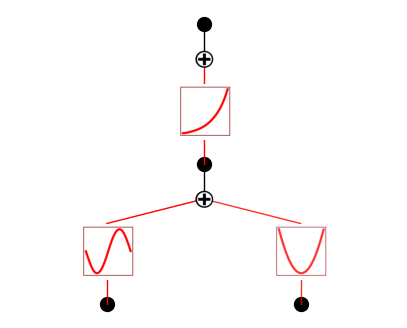

In [27]:
# ============================================================
# 10. Visualizar después de fijar funciones
# ============================================================
print("\nModelo con funciones simbólicas fijadas")
model_podado.plot()

In [28]:
# ============================================================
# 13. Mostrar fórmula simbólica
# ============================================================
# symbolic_formula() intenta devolver la expresión final.
# Dependiendo de la versión, puede regresar una estructura
# algo distinta; por eso aquí solo la imprimimos.
formula = model_podado.symbolic_formula()
print("\nFórmula simbólica encontrada:")
print(formula)


Fórmula simbólica encontrada:
([0.975889900492721*exp(1.00908086251447*(x_2 + 0.000255418864506197)**2 + 1.01903557473389*sin(3.1418399810791*x_1 - 0.00112000131048262)) - 0.799778699874878], [x_1, x_2])


In [30]:
# ------------------------------------------------------------
# 1. Definir la función objetivo
# ------------------------------------------------------------
# La función recibe dos variables:
# x[:, 0] = x
# x[:, 1] = y
#
# f(x,y) = sin(x^2) + log(1 + y^2)

f = lambda x: torch.sin(x[:, [0]]**2) + torch.log(1 + x[:, [1]]**2)

In [31]:
# ------------------------------------------------------------
# 2. Crear el dataset
# ------------------------------------------------------------
# n_var=2 porque tenemos dos variables de entrada.

dataset = create_dataset(
    f,
    n_var=2,
    train_num=1000,
    test_num=1000,
    device=device
)

In [32]:
# ------------------------------------------------------------
# 3. Crear la KAN
# ------------------------------------------------------------
# width=[2,2,1]
#
# 2 entradas  -> x, y
# 2 nodos ocultos -> uno puede capturar x^2 y otro 1+y^2
# 1 salida -> combinación final

model = KAN(
    width=[2, 2, 1],
    grid=5,
    k=3,
    seed=0,
    device=device
)

checkpoint directory created: ./model
saving model version 0.0


In [33]:
# ------------------------------------------------------------
# 4. Entrenar la KAN
# ------------------------------------------------------------
# Aquí todavía aprende funciones spline, no funciones simbólicas.

resultados = model.fit(
    dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001
)


| train_loss: 1.62e-02 | test_loss: 1.63e-02 | reg: 4.34e+00 | : 100%|█| 50/50 [00:45<00:00,  1.09it

saving model version 0.1


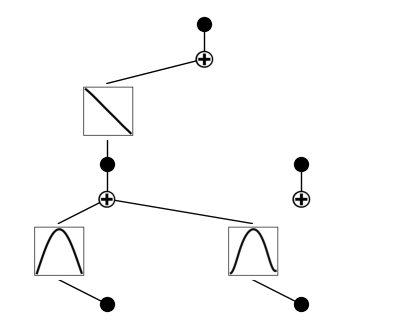

In [34]:
model.plot()

saving model version 0.2


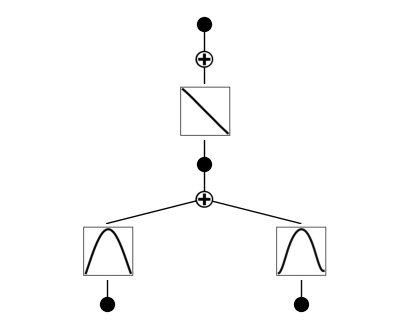

In [35]:
# ------------------------------------------------------------
# 5. Podar la red
# ------------------------------------------------------------
# Esto ayuda a eliminar conexiones poco importantes.
# Es útil antes de aplicar auto_symbolic(), porque deja una estructura
# más limpia e interpretable.

model_podado = model.prune()
model_podado.plot()

In [36]:
# ============================================================
# Reentrenar parámetros afines
# ============================================================

results_podado = model_podado.fit(
    dataset,
    opt="LBFGS",
    steps=30,
    update_grid=False
)

| train_loss: 4.65e-04 | test_loss: 4.57e-04 | reg: 5.06e+00 | : 100%|█| 30/30 [00:22<00:00,  1.33it

saving model version 0.3


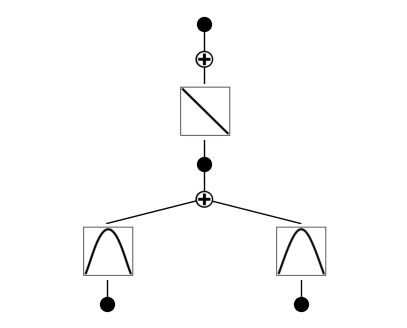

In [37]:
model_podado.plot()

In [38]:
# ------------------------------------------------------------
# 6. Aplicar auto_symbolic()
# ------------------------------------------------------------
# auto_symbolic intenta encontrar funciones conocidas que se parezcan
# a las splines aprendidas.
#
# Le damos una librería pequeña para que el ejemplo sea más claro.
# r2_threshold=0.8
# Solo aceptes una función simbólica si se parece suficientemente bien a la spline aprendida.
# Si la mejor función candidata tiene R^2 <0.8, no la fijes como simbólica.
# evita fijar
# fixing (0,0,0) with x^2, r2=0.99
# fixing (1,0,0) with 0, r2=0.0
# weight_simple=0.8
# Este parámetro controla cuánto va a preferir funciones simples.
# a weight that prioritizes simplicity (low complexity) over performance (high r2)
lib = ['x', 'x^2', 'sin', 'log']

model_podado.auto_symbolic(
    lib=lib,
    r2_threshold=0.8,
    weight_simple=0.8
)

fixing (0,0,0) with sin, r2=0.9998469948768616, c=2
fixing (0,1,0) with sin, r2=0.9999528527259827, c=2
fixing (1,0,0) with x, r2=1.0, c=1
saving model version 0.4


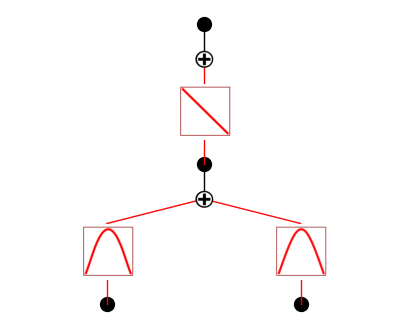

In [39]:
model_podado.plot()

In [40]:
# ------------------------------------------------------------
# 7. Obtener la fórmula simbólica
# ------------------------------------------------------------
# Después de auto_symbolic(), el modelo intenta escribir la KAN
# como una expresión matemática.

formula = model_podado.symbolic_formula()

print("Fórmula simbólica:")
print(formula)

print("\nExpresión principal:")
print(formula[0][0])

Fórmula simbólica:
([-0.799424454843561*sin(1.64247989654541*x_1 + 1.57103979587555) + 0.503562521972141*sin(1.94207978248596*x_2 - 1.57087981700897) + 1.30129309953012], [x_1, x_2])

Expresión principal:
-0.799424454843561*sin(1.64247989654541*x_1 + 1.57103979587555) + 0.503562521972141*sin(1.94207978248596*x_2 - 1.57087981700897) + 1.30129309953012


(5) $f(x_1,x_2,x_3,x_4) = \exp\!\left(\tfrac{1}{2}\big(\sin\!\big(\pi(x_1^2+x_2^2)\big) + \sin\!\big(\pi(x_3^2+x_4^2)\big)\big)\right)$ which can be represented by a [4,4,2,1] KAN.

In [41]:
# ============================================================
# Ejemplo 5:
# f(x1,x2,x3,x4) =
# exp( 0.5 * ( sin(pi(x1^2 + x2^2)) 
#            + sin(pi(x3^2 + x4^2)) ) )
# ============================================================

# Definimos la función objetivo que queremos que la KAN aprenda.
#
# En este caso, la función tiene 4 variables de entrada:
#
#   x1, x2, x3, x4
#
# Matemáticamente:
#
# f(x1,x2,x3,x4) =
# exp( 1/2 * ( sin(pi(x1^2 + x2^2))
#            + sin(pi(x3^2 + x4^2)) ) )
#
# Esta función es interesante porque tiene una estructura jerárquica:
#
#   1. Primero se forman dos grupos:
#
#        grupo 1: x1 y x2
#        grupo 2: x3 y x4
#
#   2. En cada grupo se calcula una suma de cuadrados:
#
#        x1^2 + x2^2
#        x3^2 + x4^2
#
#   3. A cada suma se le aplica una función seno:
#
#        sin(pi(x1^2 + x2^2))
#        sin(pi(x3^2 + x4^2))
#
#   4. Después se promedian esas dos cantidades multiplicando por 0.5.
#
#   5. Finalmente se aplica la función exponencial.
#
# Esta estructura puede ser representada por una KAN profunda,
# por ejemplo con arquitectura [4, 4, 2, 1].
f5 = lambda x: torch.exp(
    0.5 * (
        torch.sin(torch.pi * (x[:, [0]]**2 + x[:, [1]]**2)) +
        torch.sin(torch.pi * (x[:, [2]]**2 + x[:, [3]]**2))
    )
)

In [42]:
# ============================================================
# Creación del dataset
# ============================================================

# create_dataset genera los datos de entrenamiento y prueba.
#
# Internamente toma puntos de entrada y evalúa la función f5.
#
# Como f5 depende de 4 variables:
#
#   x1, x2, x3, x4
#
# usamos:
#
#   n_var = 4
#
# El resultado es un diccionario con datos de entrenamiento y prueba.
# Por ejemplo:
#
#   dataset5['train_input']   -> entradas de entrenamiento
#   dataset5['train_label']   -> valores reales de entrenamiento
#   dataset5['test_input']    -> entradas de prueba
#   dataset5['test_label']    -> valores reales de prueba
#
# device indica si se trabajará en CPU o GPU.
dataset5 = create_dataset(f5,n_var=4,device=device)

In [43]:
# ============================================================
# Listas para guardar las pérdidas
# ============================================================

# Aquí guardaremos el error de entrenamiento.
# Este error mide qué tan bien la KAN ajusta los datos que usó para aprender.
train_losses = []

# Aquí guardaremos el error de prueba.
# Este error mide qué tan bien la KAN generaliza a datos que no usó directamente
# durante el entrenamiento.
test_losses = []

In [44]:
k=3
steps = 100
grids = np.array([3,5,10])

In [ ]:
# ============================================================
# Entrenamiento de la KAN usando diferentes tamaños de grilla
# ============================================================

# Recorremos cada tamaño de grilla definido en el arreglo grids.
#
# Por ejemplo, si:
#
#   grids = [3, 10, 20, 50, 100]
#
# entonces primero se entrena con grid=3,
# luego se refina a grid=10,
# luego a grid=20, y así sucesivamente.
for i in range(grids.shape[0]):

    # --------------------------------------------------------
    # Primera iteración: crear el modelo desde cero
    # --------------------------------------------------------
    if i == 0:

        # Creamos una KAN con arquitectura [4, 4, 2, 1].
        #
        # Esta arquitectura significa:
        #
        #   - 4 nodos de entrada:
        #       x1, x2, x3, x4
        #
        #   - 4 nodos en la primera capa oculta
        #
        #   - 2 nodos en la segunda capa oculta
        #
        #   - 1 nodo de salida
        #
        # La arquitectura [4,4,2,1] es adecuada para este ejemplo
        # porque la función tiene una estructura jerárquica.
        #
        # De forma intuitiva:
        #
        #   - La primera parte puede construir transformaciones
        #     de las variables individuales.
        #
        #   - La siguiente capa puede combinar variables por grupos,
        #     por ejemplo (x1,x2) y (x3,x4).
        #
        #   - La última capa combina esos grupos y produce la salida final.
        #
        # grid=grids[i] indica el tamaño inicial de la grilla.
        #
        # k=k indica el grado de las splines.
        # Si k=3, se usan splines cúbicas.
        #
        # seed=1 fija la semilla para que el experimento sea reproducible.
        #
        # device=device indica si el modelo se entrena en CPU o GPU.
        model = KAN(
            width=[4, 4, 2, 1],
            grid=grids[i],
            k=k,
            seed=1,
            device=device
        )

    # --------------------------------------------------------
    # Siguientes iteraciones: refinar la grilla
    # --------------------------------------------------------
    if i != 0:

        # refine aumenta la resolución de la grilla del modelo.
        #
        # La idea es no empezar desde cero cada vez.
        # En lugar de eso, tomamos el modelo que ya aprendió con una grilla
        # más pequeña y lo pasamos a una grilla más fina.
        #
        # Esto permite que el modelo:
        #
        #   1. Aprenda primero una aproximación general de la función.
        #   2. Después mejore los detalles con una grilla más grande.
        #
        # Dicho de forma sencilla:
        #
        #   grid pequeño  -> aproximación más simple
        #   grid grande   -> aproximación más detallada
        model = model.refine(grids[i])

    # --------------------------------------------------------
    # Entrenamiento del modelo
    # --------------------------------------------------------

    # Entrenamos la KAN usando el optimizador LBFGS.
    #
    # LBFGS es un optimizador usado para ajustar los parámetros del modelo.
    # En este caso ajusta las funciones aprendibles de las conexiones
    # de la KAN.
    #
    # steps indica cuántos pasos de entrenamiento se harán
    # para el tamaño de grilla actual.
    results = model.fit(
        dataset5,
        opt='LBFGS',
        steps=steps
    )

    # results['train_loss'] contiene los errores de entrenamiento
    # registrados durante los steps de esta grilla.
    #
    # Usamos += porque queremos acumular los errores de todas las grillas
    # en una sola lista.
    train_losses += results['train_loss']

    # results['test_loss'] contiene los errores de prueba.
    #
    # También los acumulamos para después graficar cómo cambia el error
    # a lo largo de todo el proceso de entrenamiento y refinamiento.
    test_losses += results['test_loss']

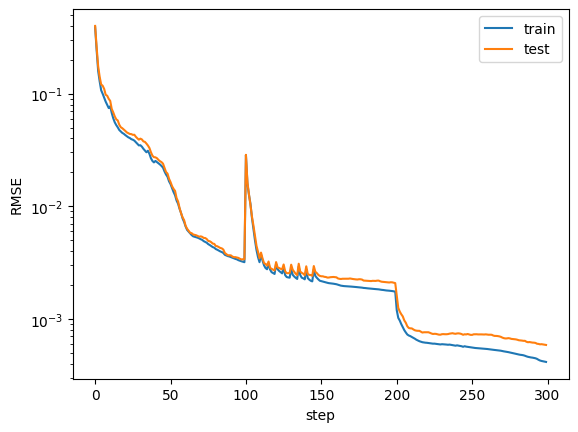

In [115]:
# ============================================================
# Gráfica de las pérdidas
# ============================================================

# Graficamos el error de entrenamiento.
plt.plot(train_losses)

# Graficamos el error de prueba.
plt.plot(test_losses)

# Agregamos una leyenda para distinguir ambas curvas.
plt.legend(['train', 'test'])

# El eje y muestra el error.
#
# En este ejemplo, la pérdida reportada por model.fit se interpreta como RMSE.
# RMSE significa Root Mean Squared Error, o raíz del error cuadrático medio.
#
# Mientras más pequeño sea el RMSE, mejor está aproximando la KAN la función.
plt.ylabel('RMSE')

# El eje x representa los pasos de entrenamiento acumulados.
#
# Por ejemplo, si steps = 200:
#
#   pasos 0 a 199     -> entrenamiento con la primera grilla
#   pasos 200 a 399   -> entrenamiento después del primer refine
#   pasos 400 a 599   -> entrenamiento después del segundo refine
#
# y así sucesivamente.
plt.xlabel('step')

# Usamos escala logarítmica en el eje y.
#
# Esto es útil porque el error puede disminuir mucho,
# por ejemplo de 10^-1 a 10^-4 o incluso menos.
#
# En escala logarítmica se aprecia mejor la caída del error.
plt.yscale('log')

En esta gráfica observamos que, después de cada refinamiento de la grilla, el error aumenta momentáneamente pero luego continúa disminuyendo hasta valores menores que en la etapa anterior. Esto sugiere que una grilla más fina le da a la KAN una representación más flexible y puede mejorar su capacidad de aproximar la función.

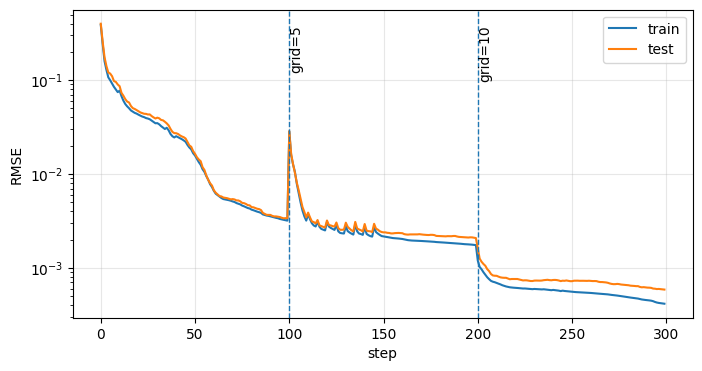

In [116]:
plt.figure(figsize=(8, 4))

plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")

# Líneas verticales para indicar los refinamientos
for j in range(1, len(grids)):
    plt.axvline(
        x=j * steps,
        linestyle="--",
        linewidth=1
    )
    plt.text(
        j * steps,
        max(train_losses),
        f"grid={grids[j]}",
        rotation=90,
        verticalalignment="top"
    )

plt.legend()
plt.ylabel("RMSE")
plt.xlabel("step")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()

scale controla el tamaño general del diagrama.
varscale controla el tamaño visual de los nombres de las variables de entrada.

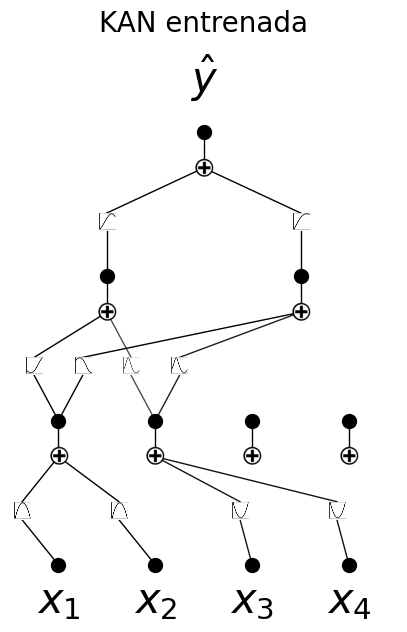

In [117]:
model.plot(
    in_vars=[r'$x_1$', r'$x_2$', r'$x_3$', r'$x_4$'],
    out_vars=[r'$\hat{y}$'],
    title='KAN entrenada',
    scale=0.5,
    varscale=1.5
)

In [118]:
# ============================================================
# Poda del modelo
# ============================================================

# prune() elimina conexiones o nodos que el modelo considera
# poco importantes.
#
# El objetivo es obtener una KAN más simple e interpretable.

model_podado = model.prune()

saving model version 0.6


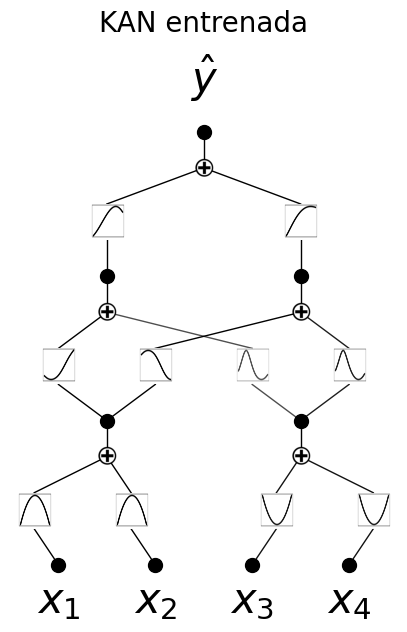

In [119]:
model_podado.plot(
    in_vars=[r'$x_1$', r'$x_2$', r'$x_3$', r'$x_4$'],
    out_vars=[r'$\hat{y}$'],
    title='KAN entrenada',
    scale=0.5,
    varscale=1.5
)

In [120]:
from kan.utils import SYMBOLIC_LIB

print("\n".join(SYMBOLIC_LIB.keys()))

x
x^2
x^3
x^4
x^5
1/x
1/x^2
1/x^3
1/x^4
1/x^5
sqrt
x^0.5
x^1.5
1/sqrt(x)
1/x^0.5
exp
log
abs
sin
cos
tan
tanh
sgn
arcsin
arccos
arctan
arctanh
0
gaussian


In [121]:
# ============================================================
# Auto symbolic
# ============================================================

# auto_symbolic intenta reemplazar funciones aprendidas por splines
# con funciones simbólicas conocidas.
#
# Por ejemplo:
#   sin, exp, x^2, x, etc.
#
# Esto ayuda a interpretar qué funciones encontró la KAN.

model_podado.auto_symbolic(
    r2_threshold=0.8,
    weight_simple=0.8
)

fixing (0,0,0) with x^2, r2=1.0000003576278687, c=2
fixing (0,0,1) with 0
fixing (0,1,0) with x^2, r2=1.0000003576278687, c=2
fixing (0,1,1) with 0
fixing (0,2,0) with 0
fixing (0,2,1) with x^2, r2=1.0000004768371582, c=2
fixing (0,3,0) with 0
fixing (0,3,1) with x^2, r2=1.0000003576278687, c=2
fixing (1,0,0) with cos, r2=0.9989370107650757, c=2
fixing (1,0,1) with x, r2=0.9385743141174316, c=1
For (1,1,0) the best fit was 0, but r^2 = 0.0 and this is lower than 0.8. This edge was omitted, keep training or try a different threshold.
For (1,1,1) the best fit was 0, but r^2 = 0.0 and this is lower than 0.8. This edge was omitted, keep training or try a different threshold.
For (2,0,0) the best fit was 0, but r^2 = 0.0 and this is lower than 0.8. This edge was omitted, keep training or try a different threshold.
fixing (2,1,0) with cos, r2=0.999688982963562, c=2
saving model version 0.7


In [122]:
# ============================================================
# Obtener fórmula simbólica
# ============================================================

formula = model_podado.symbolic_formula()

print("Fórmula simbólica:")
print(formula)

print("\nExpresión principal:")
print(formula[0][0])

Fórmula simbólica:
([-4.99879503250122*cos(0.660636732423364*(6.03980438314352e-5 - x_1)**2 + 0.660617150882054*(7.05170153113871e-5 - x_2)**2 - 4.30408125665497 + 0.464238974780912*exp(-3.046861877682*(-(9.34144481292663e-6 - x_4)**2 - 0.999929688220967*(1.69437266802468e-5 - x_3)**2 + 0.502706197974488)**2)) - 5.57017803192139 + 3.69829034805298*exp(-0.681288301771057*(-cos(1.42433137673637*(6.03980438314352e-5 - x_1)**2 + 1.42428915897535*(7.05170153113871e-5 - x_2)**2 + 7.25035881503973) + 0.467943764606717 - 0.333578924317357*exp(-3.046861877682*(-(9.34144481292663e-6 - x_4)**2 - 0.999929688220967*(1.69437266802468e-5 - x_3)**2 + 0.502706197974488)**2))**2)], [x_1, x_2, x_3, x_4])

Expresión principal:
-4.99879503250122*cos(0.660636732423364*(6.03980438314352e-5 - x_1)**2 + 0.660617150882054*(7.05170153113871e-5 - x_2)**2 - 4.30408125665497 + 0.464238974780912*exp(-3.046861877682*(-(9.34144481292663e-6 - x_4)**2 - 0.999929688220967*(1.69437266802468e-5 - x_3)**2 + 0.50270619797448

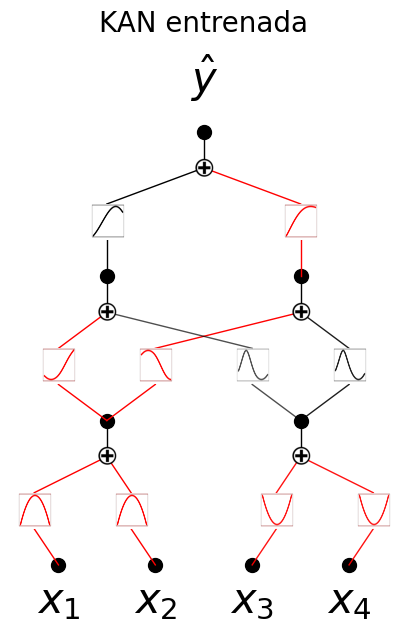

In [123]:
model_podado.plot(
    in_vars=[r'$x_1$', r'$x_2$', r'$x_3$', r'$x_4$'],
    out_vars=[r'$\hat{y}$'],
    title='KAN entrenada',
    scale=0.5,
    varscale=1.5
)

In [ ]:
import torch
from kan.utils import add_symbolic, SYMBOLIC_LIB

# ============================================================
# Agregar nuevas funciones simbólicas a la biblioteca de KAN
# ============================================================
#
# En KAN, auto_symbolic() compara las splines aprendidas contra
# funciones simbólicas conocidas.
#
# Si queremos que auto_symbolic() también considere funciones nuevas,
# tenemos que agregarlas a SYMBOLIC_LIB usando add_symbolic().
#
# La estructura general es:
#
# add_symbolic(
#     name='nombre_de_la_funcion',
#     fun=funcion_en_pytorch,
#     c=complejidad
# )
#
# Donde:
#
# name:
#     Es el nombre con el que aparecerá la función dentro de SYMBOLIC_LIB.
#     Ese mismo nombre se usa después dentro de auto_symbolic(lib=[...]).
#
# fun:
#     Es la función matemática que queremos agregar.
#     Debe estar escrita para trabajar con tensores de PyTorch.
#     Por eso usamos operaciones como:
#         x**2
#         x**3
#         torch.exp(x)
#         torch.sin(x)
#         torch.cos(x)
#
#     No conviene usar funciones de NumPy como np.exp o np.sin,
#     porque KAN trabaja internamente con tensores de PyTorch.
#
# c:
#     Es una medida de complejidad de la función.
#     Mientras más pequeño sea c, más simple considera KAN esa función.
#
#     Por ejemplo:
#         c = 1  -> función muy simple
#         c = 2  -> función simple o moderada
#         c = 3  -> función un poco más compleja
#         c = 4  -> función más compleja
#
#   La complejidad c no es una medida matemática estricta, sino una guía
#     Es una puntuación que le damos a la función para indicarle a KAN qué tan simple o complicada queremos considerarla. 
#     Funciones básicas reciben valores bajos; combinaciones, productos, cocientes o composiciones reciben valores más altos.
#     Este valor importa porque auto_symbolic() no solo busca buen ajuste,
#     también puede preferir funciones más simples cuando usamos weight_simple.
# ============================================================


# ------------------------------------------------------------
# Función 1:
# f(x) = x^3 + x
# ------------------------------------------------------------
#
# Esta función combina una parte cúbica y una parte lineal.
#
# Matemáticamente:
#
#     f(x) = x^3 + x
#
# En PyTorch:
#
#     x**3 + x
#
# Como es más compleja que x, x^2 o x^3 solas,
# le asignamos una complejidad moderada: c = 2.
# ------------------------------------------------------------

add_symbolic(
    name='x^3+x',
    fun=lambda x: x**3 + x,
    c=3
)


# ------------------------------------------------------------
# Función 2:
# f(x) = exp(-x)
# ------------------------------------------------------------
#
# Esta función representa un decaimiento exponencial.
#
# Matemáticamente:
#
#     f(x) = e^{-x}
#
# En PyTorch:
#
#     torch.exp(-x)
#
# Es útil cuando esperamos una relación donde el efecto disminuye
# conforme aumenta x. Por ejemplo, distancia a zonas urbanas,
# distancia a carreteras o alguna variable de accesibilidad.
#
# Le asignamos c = 2 porque sigue siendo una función sencilla,
# aunque un poco más especializada que x o x^2.
# ------------------------------------------------------------

add_symbolic(
    name='exp(-x)',
    fun=lambda x: torch.exp(-x),
    c=2
)


# ============================================================
# Verificar que las funciones fueron agregadas
# ============================================================

print("Funciones agregadas correctamente:\n")

print("'x^3+x' está en SYMBOLIC_LIB:", 'x^3+x' in SYMBOLIC_LIB.keys())
print("'exp(-x)' está en SYMBOLIC_LIB:", 'exp(-x)' in SYMBOLIC_LIB.keys())


# ============================================================
# Mostrar la biblioteca completa en forma de columna
# ============================================================

print("\nFunciones disponibles en SYMBOLIC_LIB:\n")

for i, name in enumerate(SYMBOLIC_LIB.keys(), start=1):
    print(f"{i:02d}. {name}")

In [ ]:
model.auto_symbolic(
    lib=[
        'x',
        'x^2',
        'x^3',
        'x^3+x',
        'sin',
        'exp',
        'exp(-x)'
    ],
    weight_simple=0.8,
    r2_threshold=0.8
)

(4) $f(x_1, \dots, x_{100}) = \exp\!\left(\tfrac{1}{100} \sum_{i=1}^{100} \sin^2\!\left(\tfrac{\pi x_i}{2}\right)\right)$ which can be represented by a [100,1,1] KAN.

In [98]:
# ============================================================
# Ejemplo KAN de alta dimensionalidad
# f(x1,...,x100) = exp( (1/100) * sum sin^2(pi*xi/2) )
# Arquitectura: [100,1,1]
# ============================================================

import torch
from kan import *

if torch.cuda.is_available():
    device = torch.device("cuda")   # Windows/Linux con NVIDIA
elif torch.backends.mps.is_available():
    #device = torch.device("mps")
    device = torch.device("cpu")     # macOS con Apple Silicon
else:
    device = torch.device("cpu")    # CPU

print("Usando dispositivo:", device)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version usada por PyTorch:", torch.version.cuda)

# ------------------------------------------------------------
# 1. Definir la función objetivo
# ------------------------------------------------------------
# x tiene forma: [n_muestras, 100]
#
# Para cada variable xi calculamos:
# sin^2(pi*xi/2)
#
# Luego sacamos el promedio sobre las 100 variables
# y finalmente aplicamos exp.

def f(x):
    return torch.exp(
        torch.mean(
            torch.sin(torch.pi * x / 2)**2,
            dim=1,
            keepdim=True
        )
    )


Usando dispositivo: cuda
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA version usada por PyTorch: 12.1


In [99]:
# ------------------------------------------------------------
# 2. Crear dataset
# ------------------------------------------------------------
# n_var=100 porque la función tiene 100 variables de entrada.

dataset = create_dataset(
    f,
    n_var=100,
    train_num=5000,
    test_num=1000,
    device=device
)


In [100]:
# ------------------------------------------------------------
# 3. Crear modelo KAN
# ------------------------------------------------------------
# width=[100,1,1]
#
# 100 entradas
# 1 nodo oculto
# 1 salida

model = KAN(
    width=[100, 1, 1],
    grid=5,
    k=3,
    seed=0,
    device=device
)

checkpoint directory created: ./model
saving model version 0.0


In [101]:
# ------------------------------------------------------------
# 4. Entrenar
# ------------------------------------------------------------
# Usamos un lamb pequeño o incluso 0.
# ¿Por qué?
# Porque las 100 variables sí son importantes.
# Si usamos mucha regularización, la red podría intentar apagar conexiones.

results = model.fit(
    dataset,
    opt="LBFGS",
    steps=50
)

print(results)

| train_loss: 1.91e-04 | test_loss: 2.78e-04 | reg: 7.79e+00 | : 100%|█| 50/50 [00:37<00:00,  1.34it

saving model version 0.1
{'train_loss': [array(0.05490226, dtype=float32), array(0.02005176, dtype=float32), array(0.01131973, dtype=float32), array(0.00671554, dtype=float32), array(0.00431393, dtype=float32), array(0.00274204, dtype=float32), array(0.00186041, dtype=float32), array(0.00139579, dtype=float32), array(0.00116293, dtype=float32), array(0.00100459, dtype=float32), array(0.0009345, dtype=float32), array(0.00089127, dtype=float32), array(0.00084674, dtype=float32), array(0.00081446, dtype=float32), array(0.00079161, dtype=float32), array(0.00076287, dtype=float32), array(0.00073583, dtype=float32), array(0.00071463, dtype=float32), array(0.00069425, dtype=float32), array(0.00066349, dtype=float32), array(0.00062669, dtype=float32), array(0.00059162, dtype=float32), array(0.00056737, dtype=float32), array(0.00052017, dtype=float32), array(0.00047941, dtype=float32), array(0.00043448, dtype=float32), array(0.00041092, dtype=float32), array(0.00037504, dtype=float32), array(0.

In [102]:
# ------------------------------------------------------------
# 5. Aplicar auto_symbolic()
# ------------------------------------------------------------
# La función interna puede aparecer como cos,
# porque sin^2(pi*x/2) = (1 - cos(pi*x))/2

model.auto_symbolic()

fixing (0,0,0) with cos, r2=0.9999597668647766, c=2
fixing (0,1,0) with cos, r2=0.9999608397483826, c=2
fixing (0,2,0) with cos, r2=0.999952495098114, c=2
fixing (0,3,0) with sin, r2=0.9999576807022095, c=2
fixing (0,4,0) with sin, r2=0.9999630451202393, c=2
fixing (0,5,0) with cos, r2=0.9999589920043945, c=2
fixing (0,6,0) with cos, r2=0.9999583959579468, c=2
fixing (0,7,0) with cos, r2=0.9999639391899109, c=2
fixing (0,8,0) with cos, r2=0.9999586939811707, c=2
fixing (0,9,0) with cos, r2=0.9999632239341736, c=2
fixing (0,10,0) with sin, r2=0.9999575614929199, c=2
fixing (0,11,0) with cos, r2=0.999957799911499, c=2
fixing (0,12,0) with cos, r2=0.9999500513076782, c=2
fixing (0,13,0) with cos, r2=0.9999530911445618, c=2
fixing (0,14,0) with cos, r2=0.9999618530273438, c=2
fixing (0,15,0) with cos, r2=0.999967098236084, c=2
fixing (0,16,0) with cos, r2=0.999958872795105, c=2
fixing (0,17,0) with cos, r2=0.9999610781669617, c=2
fixing (0,18,0) with cos, r2=0.999963104724884, c=2
fixing (

In [103]:
# ------------------------------------------------------------
# 6. Obtener fórmula simbólica
# ------------------------------------------------------------

formula = model.symbolic_formula()

print("Fórmula simbólica completa:")
print(formula)

print("\nExpresión principal:")
print(formula[0][0])

Fórmula simbólica completa:
([0.851713914489444*(0.00484293905267188*sin(3.14295983314514*x_100 - 1.5712798833847) - 0.00484832770568668*sin(3.13527989387512*x_11 + 1.57103979587555) + 0.0048435648125982*sin(3.14111995697021*x_21 - 1.57103979587555) + 0.00484317007967785*sin(3.14271998405457*x_22 - 1.5707198381424) + 0.00484313745712245*sin(3.14032006263733*x_29 - 1.57223987579346) - 0.0048424796677781*sin(3.1450400352478*x_4 + 1.57199990749359) + 0.00484304818994813*sin(3.14039993286133*x_5 - 1.57191979885101) - 0.00484379969499708*sin(3.13944005966187*x_55 + 1.5707198381424) - 0.00484632942588405*sin(3.14055991172791*x_62 + 1.5707198381424) + 0.00483663785781191*sin(3.14432001113892*x_67 - 1.57207989692688) + 0.00483832177480795*sin(3.14335989952087*x_68 - 1.57167983055115) + 0.00484128301313227*sin(3.14247989654541*x_79 - 1.57143986225128) - 0.00484116319938334*sin(3.14287996292114*x_85 + 1.57055985927582) - 0.00483633950971434*sin(3.14432001113892*x_87 + 1.57079982757568) - 0.00484